# Exploratory Data Analysis (EDA)


Perform EDA on US stocks and ETFs collected from Yahoo Finance.



## 1. Import Libraries

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
import time 
warnings.filterwarnings("ignore")

plt.style.use('default')

pd.set_option('display.max_columns', None)


# 2. Load Datasets

The datasets generated during Week 2 are loaded.

The datasets include:

- Adjusted close prices
- Daily returns
- Log returns
- Normalized prices
- Rolling volatility

In [49]:
adj_close = pd.read_csv(
    "../data/cleaned/adj_close_cleaned.csv",
    index_col=0,
    parse_dates=True
)

returns = pd.read_csv(
    "../data/processed/returns.csv",
    index_col=0,
    parse_dates=True
)

log_returns = pd.read_csv(
    "../data/processed/log_returns.csv",
    index_col=0,
    parse_dates=True
)

normalized_prices = pd.read_csv(
    "../data/processed/normalized_prices.csv",
    index_col=0,
    parse_dates=True
)

rolling_volatility = pd.read_csv(
    "../data/processed/rolling_volatility.csv",
    index_col=0,
    parse_dates=True
)

assert returns.index[-1] == adj_close.index[-1]

row_diff = len(adj_close) - len(returns)

assert row_diff in [0, 1]

print("adj_close shape:", adj_close.shape)
print("returns shape:", returns.shape)

print("adj_close start:", adj_close.index[0])
print("adj_close end:", adj_close.index[-1])

print("returns start:", returns.index[0])
print("returns end:", returns.index[-1])

print("Row Difference:", row_diff)

print(f"Adj Close Shape: {adj_close.shape}")

print(f"Returns Shape: {returns.shape}")

print("Datasets loaded successfully.")



adj_close shape: (2116, 108)
returns shape: (2115, 108)
adj_close start: 2018-01-02 00:00:00
adj_close end: 2026-06-03 00:00:00
returns start: 2018-01-03 00:00:00
returns end: 2026-06-03 00:00:00
Row Difference: 1
Adj Close Shape: (2116, 108)
Returns Shape: (2115, 108)
Datasets loaded successfully.


## 3. Define Asset Universe

The ETF and stock universes are defined once here and reused throughout the notebook.

In [50]:
etf_tickers = [
    'SPY',
    'QQQ',
    'IWM',
    'DIA',
    'XLK',
    'XLF',
    'XLV',
    'XLE',
    'XLY',
    'XLP',
    'XLI',
    'XLU',
    'VNQ',
    'GLD',
    'SLV',
    'TLT'
]

available_etfs = [
    ticker for ticker in etf_tickers
    if ticker in returns.columns
]

stock_columns = [
    col for col in returns.columns
    if col not in available_etfs
]

stock_returns = returns[stock_columns]
etf_returns = returns[available_etfs]

print("Number of Stocks:", len(stock_columns))
print("Number of ETFs:", len(available_etfs))

##Most recent 252 trading days
recent_prices = adj_close.tail(252)
recent_returns = returns.tail(252)
recent_log_returns = log_returns.tail(252)
recent_stock_returns = recent_returns[stock_columns]
recent_etf_returns = recent_returns[available_etfs]

print("Recent period:",
    recent_returns.index[0].date(),
    "to",
    recent_returns.index[-1].date()
)

print(
    "Trading Days:",
    len(recent_returns)
)

Number of Stocks: 93
Number of ETFs: 15
Recent period: 2025-06-03 to 2026-06-03
Trading Days: 252


In [51]:
company_info = {}

for ticker in stock_columns:

    try:
        company_info[ticker] = (yf.Ticker(ticker).info.get("longName"))
        time.sleep(0.5)

    except Exception:
        company_info[ticker] = None


def clean_company_name(name):
    if pd.isna(name) or name is None:
        return None
    remove_words = [
        "Class A",
        "Class B",
        "Class C",
        "Common Stock"]

    for word in remove_words:
        name = name.replace(word, "")
    return name.strip()


def remove_same_company_pairs(pair_df,asset1_col,asset2_col):

    pair_df = pair_df.copy()

    pair_df["Company_1"] = pair_df[asset1_col].map(
        lambda x: clean_company_name(
            company_info.get(x))
    )

    pair_df["Company_2"] = pair_df[asset2_col].map(
        lambda x: clean_company_name(
            company_info.get(x))
    )

    pair_df = pair_df[
        pair_df["Company_1"] != pair_df["Company_2"]
    ]

    return pair_df

# 4. Dataset Overview
To verify data is suitable for EDA we need to check these
- Number of assets
- Trading period
- Missing values
- Data types
- Summary statistics

In [52]:
print("Adjusted Close Shape:", adj_close.shape)
print("Returns Shape:", returns.shape)
print("Log Returns Shape:", log_returns.shape)
print("Rolling Volatility Shape:", rolling_volatility.shape)

Adjusted Close Shape: (2116, 108)
Returns Shape: (2115, 108)
Log Returns Shape: (2115, 108)
Rolling Volatility Shape: (2115, 108)


In [53]:
adj_close.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2116 entries, 2018-01-02 to 2026-06-03
Columns: 108 entries, AAPL to XOM
dtypes: float64(108)
memory usage: 1.8 MB


In [54]:
adj_close.describe()

,AAPL,ABBV,ABT,ADI,AMAT,AMD,AMGN,AMZN,ANET,APH,AVGO,AXP,BA,BAC,BKNG,BLK,BRK-B,BX,C,CAT,CB,COP,COST,CRM,CSCO,CVS,CVX,DE,DELL,DHR,DIA,DIS,ETN,GE,GILD,GLD,GLW,GOOG,GOOGL,GS,HD,HON,IBKR,IBM,INTC,ISRG,IWM,JNJ,JPM,KLAC,KO,LIN,LLY,LMT,LOW,LRCX,MA,MCD,META,MO,MRK,MS,MSFT,MU,NEE,NEM,NFLX,NOW,NVDA,ORCL,PANW,PEP,PFE,PG,PLD,PM,QCOM,QQQ,RTX,SCHW,SPGI,SPY,STX,T,TJX,TLT,TMO,TMUS,TSLA,TXN,UNH,UNP,V,VNQ,VZ,WDC,WELL,WFC,WMT,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,XOM
count,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000
mean,141.922093,119.921589,95.452025,158.131178,123.319488,99.030194,220.720141,144.992529,47.182308,47.052809,96.887754,170.922803,233.009993,32.751244,111.232151,664.067233,314.909036,83.527424,58.000155,244.486201,190.156395,73.291417,511.549807,205.349286,47.388673,63.863291,114.527310,310.228747,61.499554,188.660797,317.049981,116.519197,176.225625,103.248553,69.814584,196.795217,39.299566,125.783574,125.279710,354.796261,270.343178,165.355233,25.162200,141.014541,40.479096,302.808024,181.645958,141.846352,149.963077,445.962853,51.795685,299.298292,395.666030,375.123278,171.024197,61.801884,359.570267,222.535109,329.965148,37.573307,78.941793,78.214504,270.536244,94.397308,61.899718,48.025884,53.102590,104.519221,51.803147,95.380792,95.935473,131.791112,28.607031,123.133027,96.595619,88.166497,114.192100,337.345741,91.566713,60.937927,350.781481,408.003003,93.182664,17.242264,77.240584,101.365656,444.608918,132.613568,193.887963,143.842040,362.539796,187.280768,221.412999,75.854542,37.539163,60.146896,86.641136,47.462428,54.200816,31.555662,33.726878,97.529364,75.069121,62.730112,30.017067,114.062882,78.560601,76.753784
std,71.360329,51.495096,22.096344,66.430523,80.838628,69.837347,57.880149,50.514418,41.572047,33.472092,103.843166,80.685345,71.900476,9.238588,48.535071,229.686667,107.925949,44.556017,20.118215,159.343643,65.788821,28.836548,275.532211,55.680422,13.343334,13.145780,34.356595,133.560528,48.473560,58.685907,82.860381,26.240254,106.022862,83.228720,24.095631,81.305963,28.056532,71.669122,71.602936,204.982797,77.276995,32.259889,18.426419,61.300559,13.183048,129.376137,38.035275,29.327055,70.119163,380.410896,11.788120,116.382849,312.163507,91.798765,59.931859,52.944955,116.216524,55.647305,185.096468,11.138931,21.703451,40.661406,126.766473,105.714072,15.739040,20.530032,27.206220,49.712136,61.902463,57.112891,60.365345,26.146877,5.772766,29.631758,26.671347,36.252354,42.814179,142.831859,35.366700,19.111490,109.139393,137.981113,111.941825,4.251969,34.045173,17.828101,131.572471,55.249536,132.573219,41.605114,115.240767,40.808027,66.849900,11.429364,4.708588,70.056054,43.746296,16.918921,26.838012,11.275898,10.093838,30.920635,35.419731,12.552391,6.909346,25.150689,21.557191,31.476632
min,33.

In [55]:
print("Missing Values:")
adj_close.isnull().sum().sort_values(ascending=False).head(10)

Missing Values:


AAPL    0
NVDA    0
SCHW    0
RTX     0
QQQ     0
QCOM    0
PM      0
PLD     0
PG      0
PFE     0
dtype: int64

In [56]:
print("Start Date:", adj_close.index.min())
print("End Date:", adj_close.index.max())

Start Date: 2018-01-02 00:00:00
End Date: 2026-06-03 00:00:00


# 5. Price Trend Analysis


In [57]:
top_performers = (
    normalized_prices[stock_columns]
    .iloc[-1]
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

focus_assets = ['SPY'] + top_performers

The price trends of selected technology stocks and a broad market benchmark are analyzed to compare their performance and identify major market movements during the sample period.

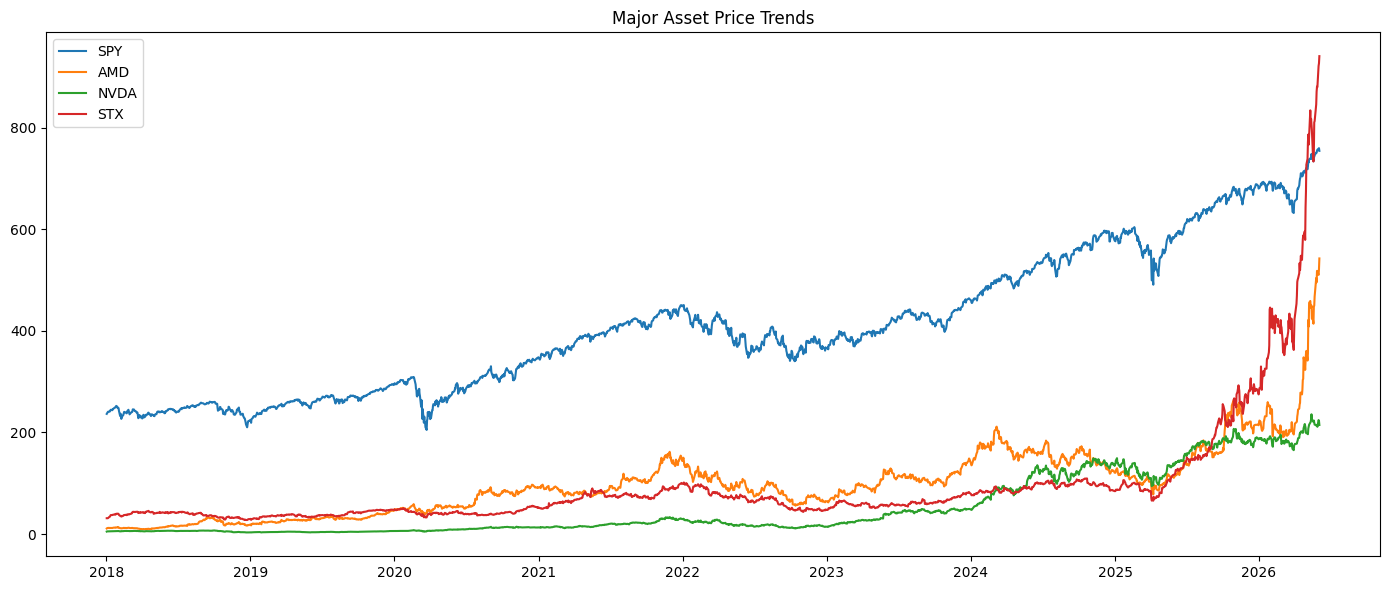

In [58]:
plt.figure(figsize=(14,6))

for asset in focus_assets:
    plt.plot(
        adj_close.index,
        adj_close[asset],
        label=asset
    )

plt.title("Major Asset Price Trends")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Normalized Price Comparison

Since assets begin the sample period at different price levels, direct comparison of raw prices can be misleading. By normalizing the price level for all of them, we can make an objective judgment regarding their performance.


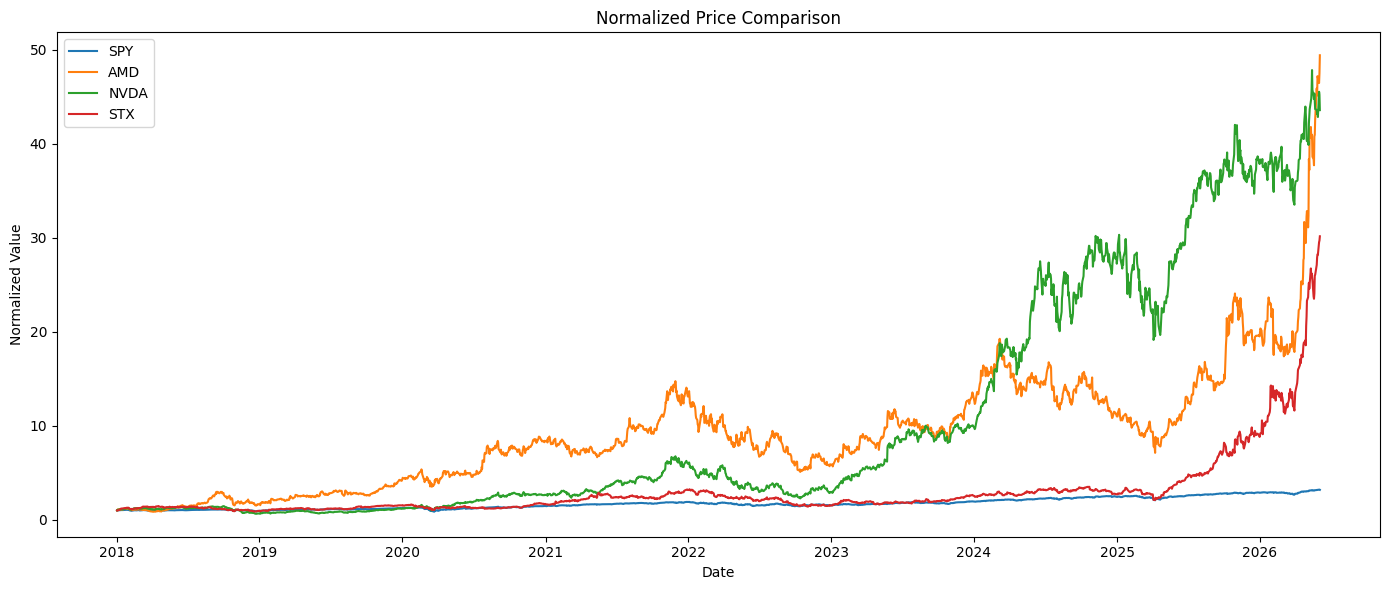

In [59]:

plt.figure(figsize=(14,6))

for asset in focus_assets:
    plt.plot(
        normalized_prices.index,
        normalized_prices[asset],
        label=asset
    )

plt.title("Normalized Price Comparison")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Top and Bottom Performing Assets

Using normalized prices, the final value of each asset represents its cumulative growth relative to the start of the sample period.


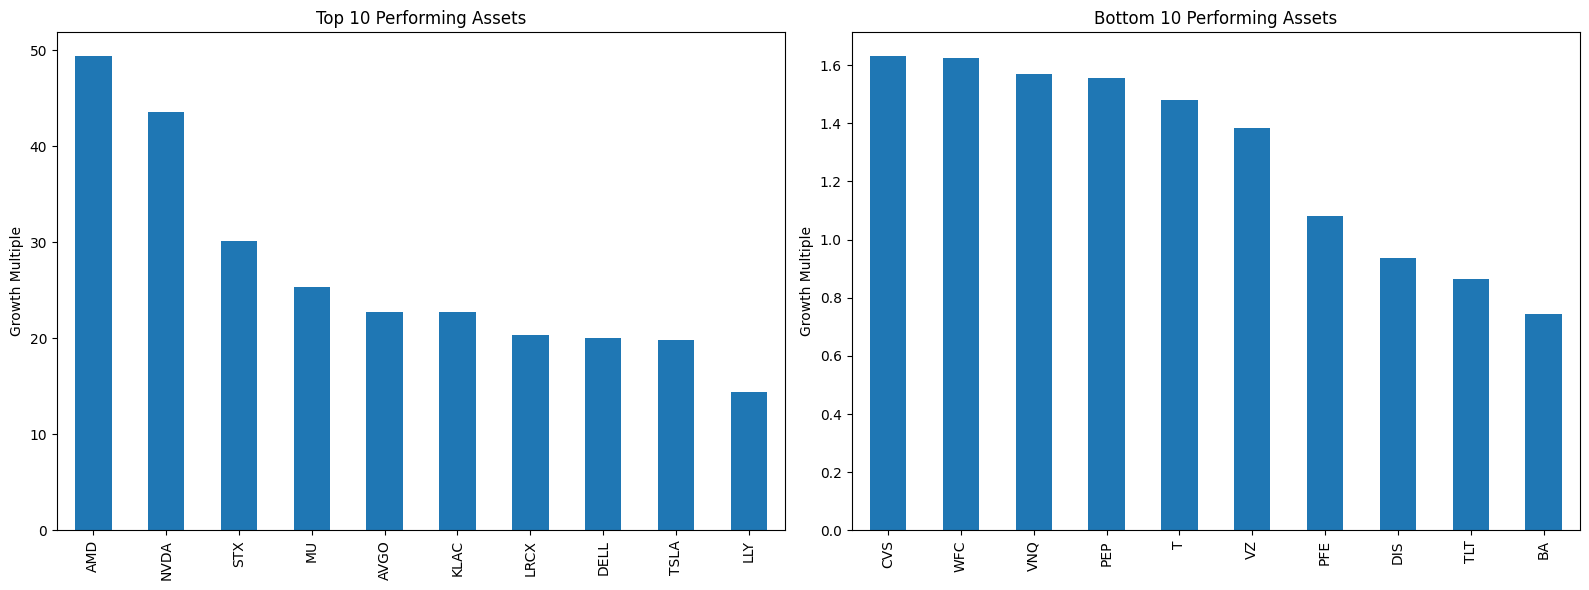

Top 10 performers:
AMD     49.409840
NVDA    43.575172
STX     30.155163
MU      25.347498
AVGO    22.726695
KLAC    22.706456
LRCX    20.372517
DELL    20.004352
TSLA    19.828097
LLY     14.403363
Name: 2026-06-03 00:00:00, dtype: float64

Bottom 10 performers:
CVS    1.631414
WFC    1.626401
VNQ    1.569029
PEP    1.556066
T      1.479169
VZ     1.383741
PFE    1.080900
DIS    0.935660
TLT    0.864287
BA     0.744398
Name: 2026-06-03 00:00:00, dtype: float64


In [60]:
performance = normalized_prices.iloc[-1].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

performance.head(10).plot(kind='bar', ax=axes[0])
axes[0].set_title("Top 10 Performing Assets")
axes[0].set_ylabel("Growth Multiple")

performance.tail(10).plot(kind='bar', ax=axes[1])
axes[1].set_title("Bottom 10 Performing Assets")
axes[1].set_ylabel("Growth Multiple")

plt.tight_layout()
plt.show()

print("Top 10 performers:")
print(performance.head(10))
print()
print("Bottom 10 performers:")
print(performance.tail(10))


# 8. Return Analysis

Returns are analysed because price levels are non-stationary and difficult to compare directly across assets.

Returns provide a standardized measure of performance.

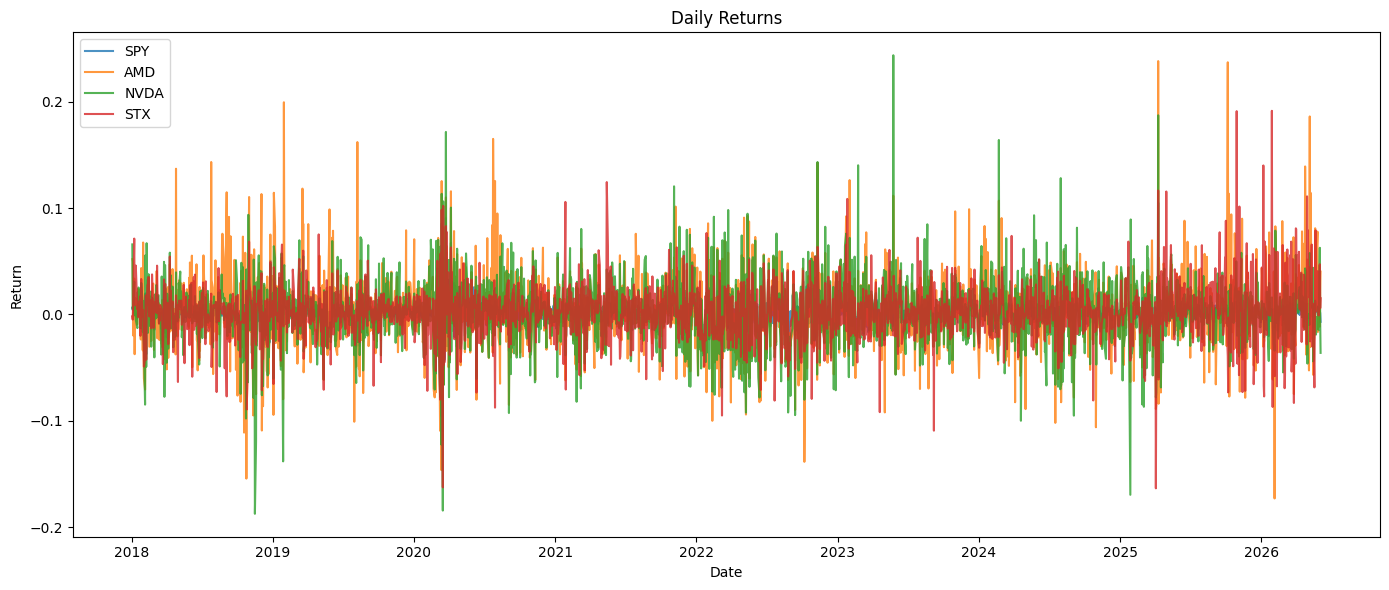

In [61]:
plt.figure(figsize=(14,6))

for asset in focus_assets:
    plt.plot(
        returns.index,
        returns[asset],
        label=asset,
        alpha=0.8
    )

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Return Summary Statistics

In [62]:
return_stats = pd.DataFrame({
    'Mean Return (Daily)': returns.mean(),
    'Volatility (Daily Std)': returns.std(),
    'Min Return': returns.min(),
    'Max Return': returns.max()
})
return_stats.head()

,Mean Return (Daily),Volatility (Daily Std),Min Return,Max Return
AAPL,0.001150,0.019207,-0.128647,0.153288
ABBV,0.000687,0.016810,-0.162524,0.137673
ABT,0.000378,0.015548,-0.100389,0.109360
ADI,0.001053,0.021658,-0.166149,0.183876
AMAT,0.001510,0.028356,-0.203576,0.161058


### Outlier Detection
To show extreme market moves

In [63]:
z_scores = (
    returns - returns.mean()
) / returns.std()

outliers = (
    z_scores.abs() > 3
)

outliers.sum().sort_values(
    ascending=False
).head(10)

GLW     42
QCOM    41
ISRG    39
AMGN    39
MRK     39
IBM     38
KO      38
TMUS    38
JNJ     38
UNH     37
dtype: int64

## 10. Most Volatile Assets

The following assets exhibited the highest return volatility during the sample period, indicating greater price fluctuations and risk.

Top 10 Most Volatile Assets:
TSLA    0.626684
AMD     0.561009
MU      0.513484
NVDA    0.506896
WDC     0.503856
LRCX    0.472234
INTC    0.470515
DELL    0.465784
ANET    0.461960
AMAT    0.450141
dtype: float64


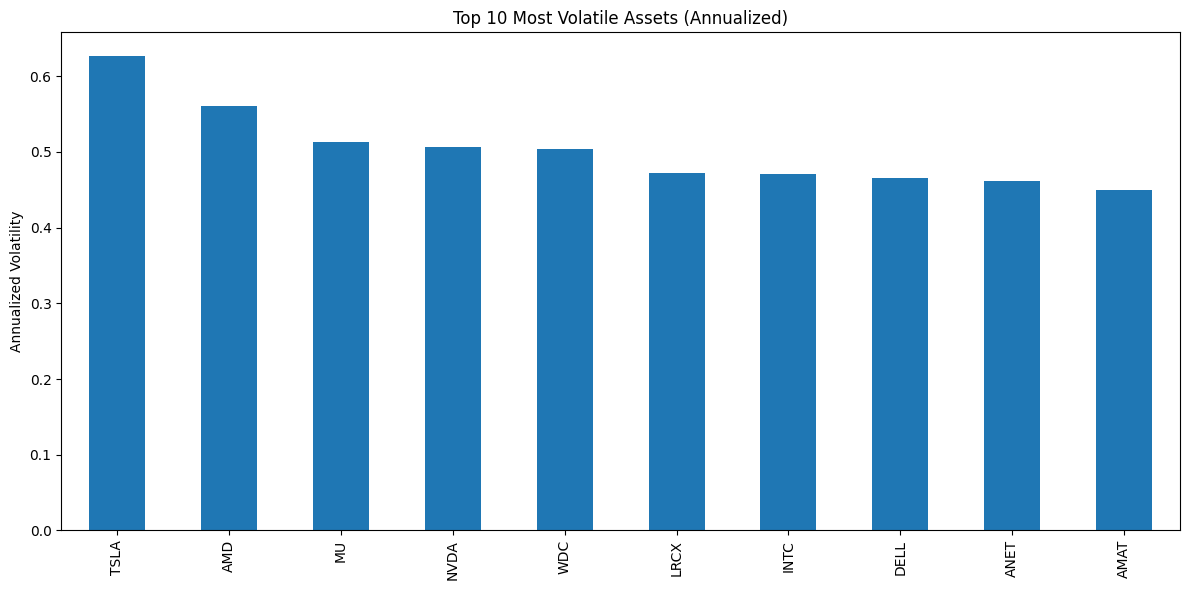

In [64]:
# Top 10 Most Volatile Assets (Annualized)

top_volatility = (returns.std()* np.sqrt(252)).sort_values(ascending=False).head(10)

print("Top 10 Most Volatile Assets:")
print(top_volatility)

plt.figure(figsize=(12,6))

top_volatility.plot(kind="bar")

plt.title( "Top 10 Most Volatile Assets (Annualized)")

plt.ylabel("Annualized Volatility")

plt.tight_layout()
plt.show()

### Least Volatile Assets

The assets below exhibited the lowest return volatility during the sample period, indicating more stable price movements and lower levels of market risk.

Top 10 Least Volatile Assets:
TLT    0.155008
XLP    0.155676
GLD    0.166154
XLV    0.174181
DIA    0.187848
SPY    0.191977
KO     0.192124
JNJ    0.194522
PG     0.200415
XLU    0.202597
dtype: float64


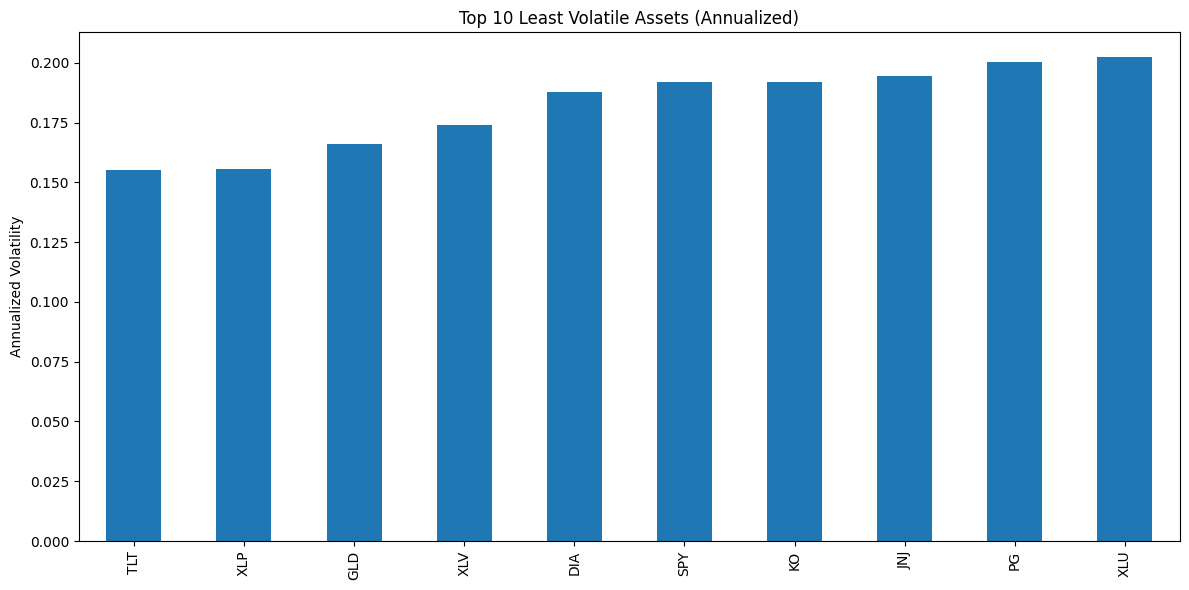

In [65]:
# Top 10 Least Volatile Assets (Annualized)

low_volatility = (returns.std()* np.sqrt(252)).sort_values(ascending=True).head(10)

print("Top 10 Least Volatile Assets:")
print(low_volatility)

plt.figure(figsize=(12,6))

low_volatility.plot(kind="bar")

plt.title("Top 10 Least Volatile Assets (Annualized)")

plt.ylabel("Annualized Volatility")

plt.tight_layout()
plt.show()

## 11. Rolling Volatility Analysis
It shows 
- Covid crash
- Bear market
- Market Stress periods

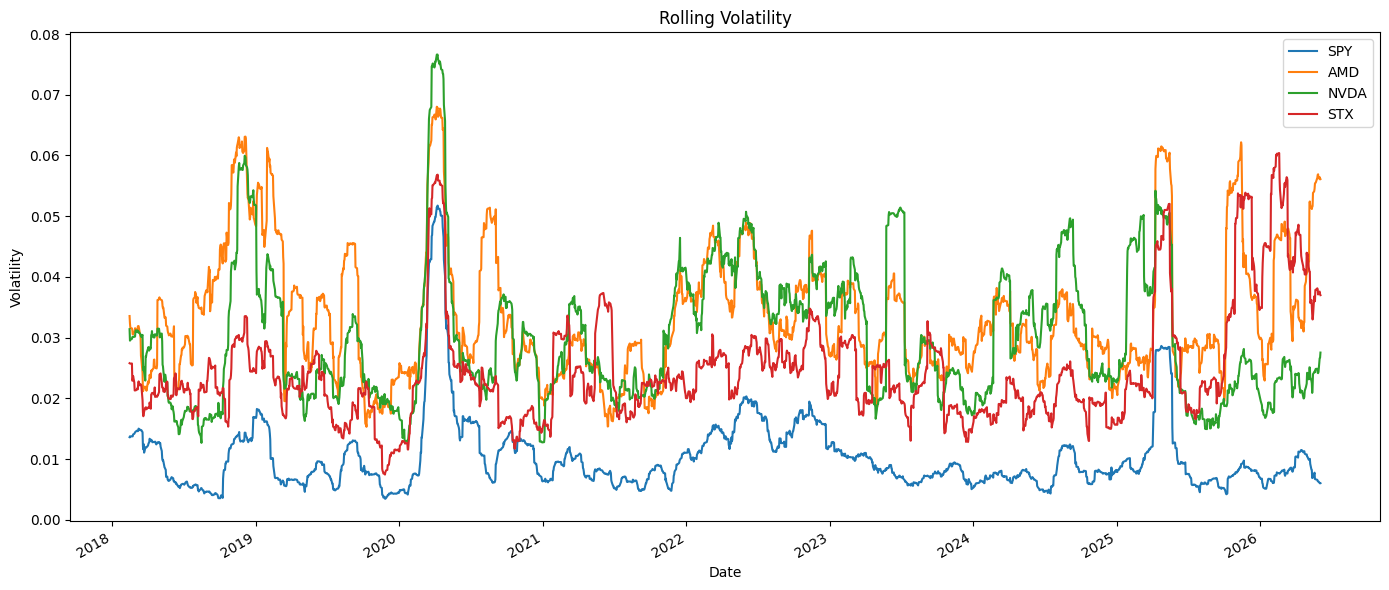

In [66]:
rolling_volatility[focus_assets].plot(
    figsize=(14,6)
)

plt.title("Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()

## 12. Return Distribution Analysis

The distribution of returns is examined to understand the frequency of different return outcomes and assess the presence of skewness and extreme market movements.

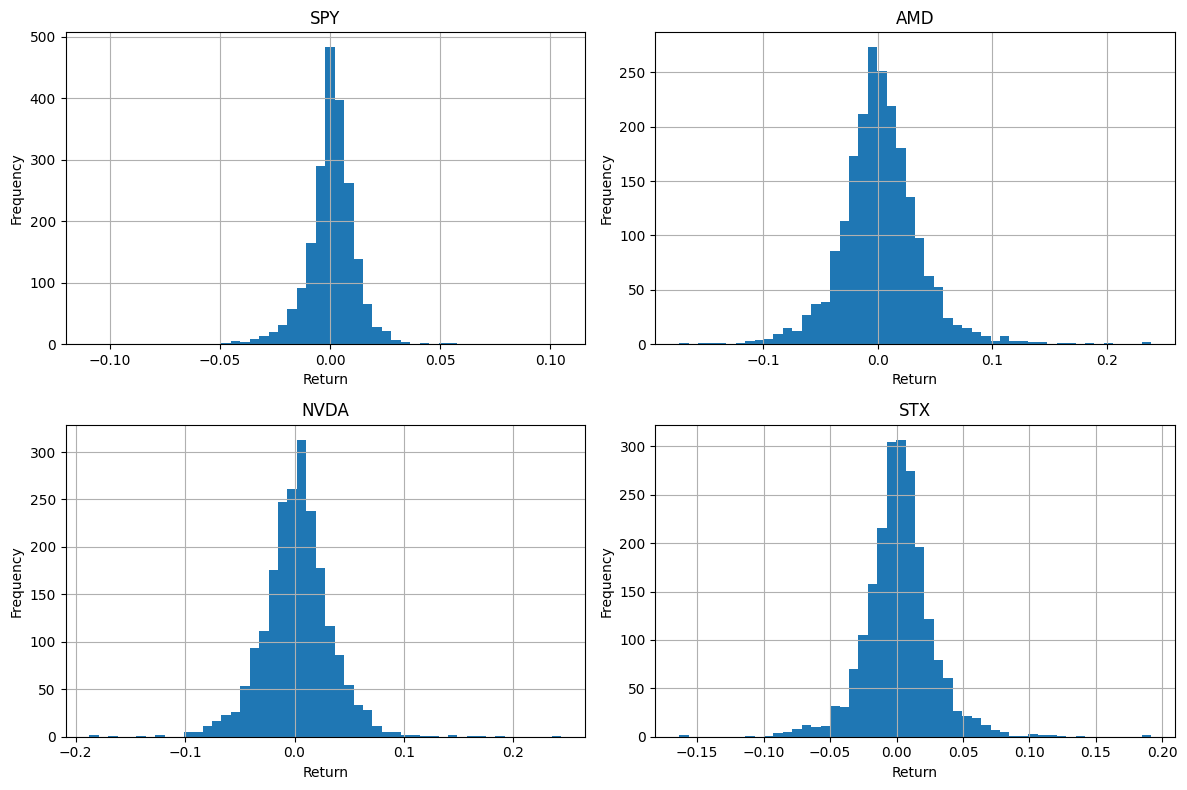

In [67]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

for ax, asset in zip(
    axes.flatten(),
    focus_assets
):

    returns[asset].hist(
        bins=50,
        ax=ax
    )

    ax.set_title(asset)
    ax.set_xlabel("Return")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 13. Skewness and Kurtosis

In [68]:
distribution_stats = pd.DataFrame({
    'Skewness': returns.skew(),
    'Kurtosis': returns.kurtosis()
})

distribution_stats.head()

,Skewness,Kurtosis
AAPL,0.148650,6.412197
ABBV,-0.906429,12.802930
ABT,-0.148682,6.621891
ADI,0.225024,7.653916
AMAT,-0.208157,3.414952


### Assets with Highest Kurtosis

Ranking assets by kurtosis helps identify securities whose return distributions exhibit the strongest tail behavior and the greatest tendency toward extreme return events.

In [69]:
distribution_stats.sort_values(
    'Kurtosis',
    ascending=False
).head(10)

,Skewness,Kurtosis
ORCL,2.203569,34.094480
MCD,0.354560,29.830423
WELL,0.093094,27.914482
CVX,-0.322182,22.973707
DELL,1.312355,20.867495
UNH,-1.363937,20.787480
VNQ,-1.092302,19.716993
DIA,-0.473918,18.991732
LOW,-0.951989,18.787029
NFLX,-0.874675,18.669684


## 14.Annualized Return

In [70]:
n_days = len(returns)

annual_return = (
    (1 + returns).prod()** (252 / n_days)- 1
)

annual_return.sort_values(
    ascending=False
).head(10)

AMD     0.591535
NVDA    0.567883
STX     0.500598
MU      0.469865
AVGO    0.450875
KLAC    0.450721
LRCX    0.432093
DELL    0.428985
TSLA    0.427479
LLY     0.374136
dtype: float64

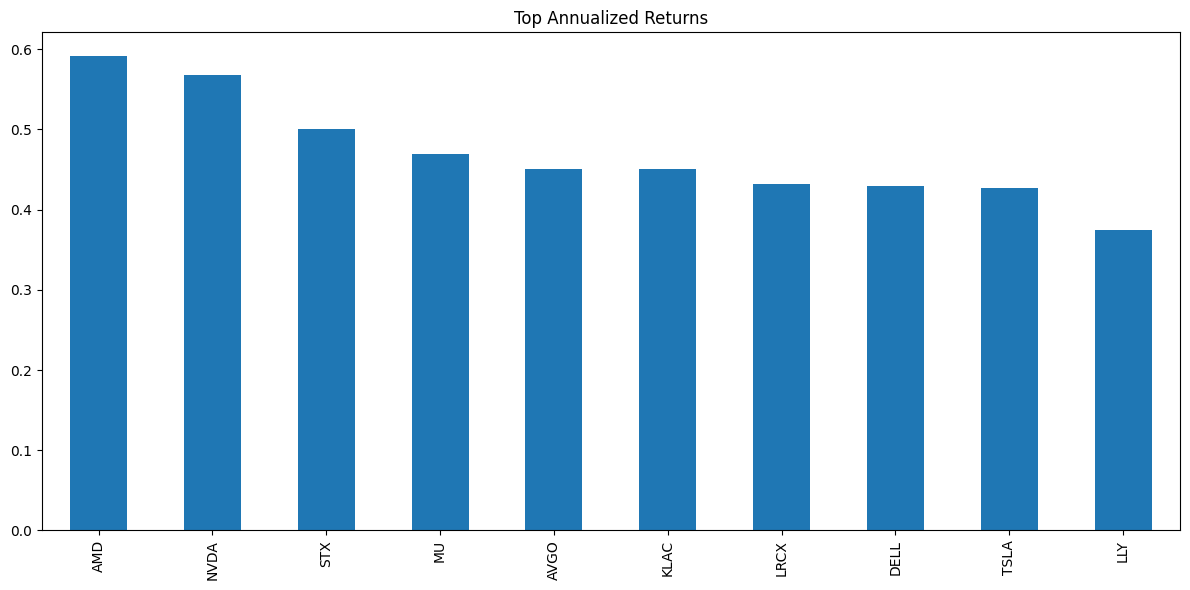

In [71]:
annual_return.sort_values(
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    "Top Annualized Returns"
)
plt.tight_layout()
plt.show()

## 15. Correlation Matrix

The correlation matrix summarizes pairwise relationships between asset returns, where values close to 1 indicate strong positive co-movement and values close to -1 indicate strong inverse relationships.

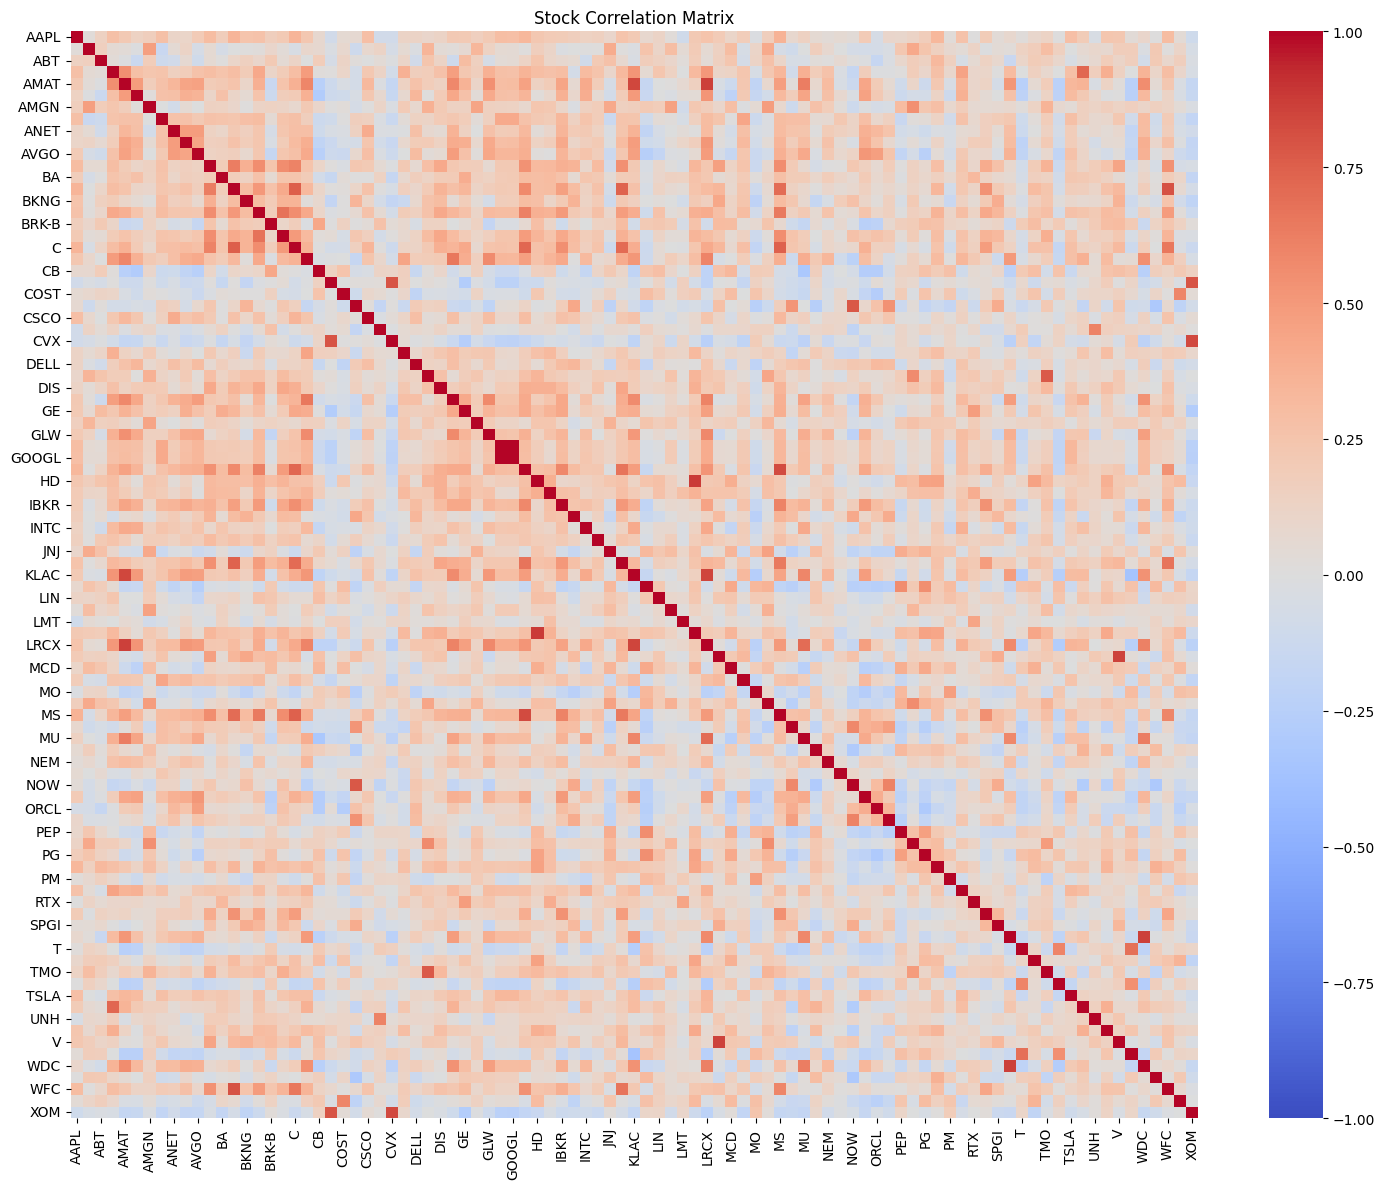

In [72]:
stock_corr = recent_stock_returns.corr()

plt.figure(figsize=(15,12))

sns.heatmap(
    stock_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title(
    "Stock Correlation Matrix"
)

plt.tight_layout()
plt.show()

## 16. Top Correlated Stock Pairs

To identify potential candidate pairs, the stock return correlation matrix is examined. Only the upper triangle of the matrix is retained to avoid duplicate pair combinations.

The top 20 most highly correlated stock pairs are selected and enriched with company information to improve interpretability. Pairs representing the same company through multiple share classes are removed to ensure that the analysis focuses on relationships between distinct firms.


In [73]:
upper_stock = stock_corr.where(
    np.triu(
        np.ones(stock_corr.shape),
        k=1
    ).astype(bool)
)

top_stock_pairs = (
    upper_stock
    .stack()
    .reset_index()
)

top_stock_pairs.columns = [
    "Stock_1",
    "Stock_2",
    "Correlation"
]

top_stock_pairs = (
    top_stock_pairs
    .sort_values(
        "Correlation",
        ascending=False
    )
    .head(20)
)

top_stock_pairs

,Stock_1,Stock_2,Correlation
3291,GOOG,GOOGL,0.996729
3585,HD,LOW,0.882509
7249,STX,WDC,0.867159
424,AMAT,LRCX,0.862974
5015,MA,V,0.857096
4330,KLAC,LRCX,0.850372
418,AMAT,KLAC,0.836215
2510,CVX,XOM,0.828972
3499,GS,MS,0.825748
1299,BAC,WFC,0.796954


In [74]:
# Unique tickers appearing in top pairs
top_stock_pairs = remove_same_company_pairs(
    top_stock_pairs,
    "Stock_1",
    "Stock_2"
)
top_stock_pairs.head(10)


,Stock_1,Stock_2,Correlation,Company_1,Company_2
3585,HD,LOW,0.882509,"The Home Depot, Inc.","Lowe's Companies, Inc."
7249,STX,WDC,0.867159,Seagate Technology Holdings plc,Western Digital Corporation
424,AMAT,LRCX,0.862974,"Applied Materials, Inc.",Lam Research Corporation
5015,MA,V,0.857096,Mastercard Incorporated,Visa Inc.
4330,KLAC,LRCX,0.850372,KLA Corporation,Lam Research Corporation
418,AMAT,KLAC,0.836215,"Applied Materials, Inc.",KLA Corporation
2510,CVX,XOM,0.828972,Chevron Corporation,Exxon Mobil Corporation
3499,GS,MS,0.825748,"The Goldman Sachs Group, Inc.",Morgan Stanley
1299,BAC,WFC,0.796954,Bank of America Corporation,Wells Fargo & Company
1979,COP,CVX,0.796180,ConocoPhillips,Chevron Corporation


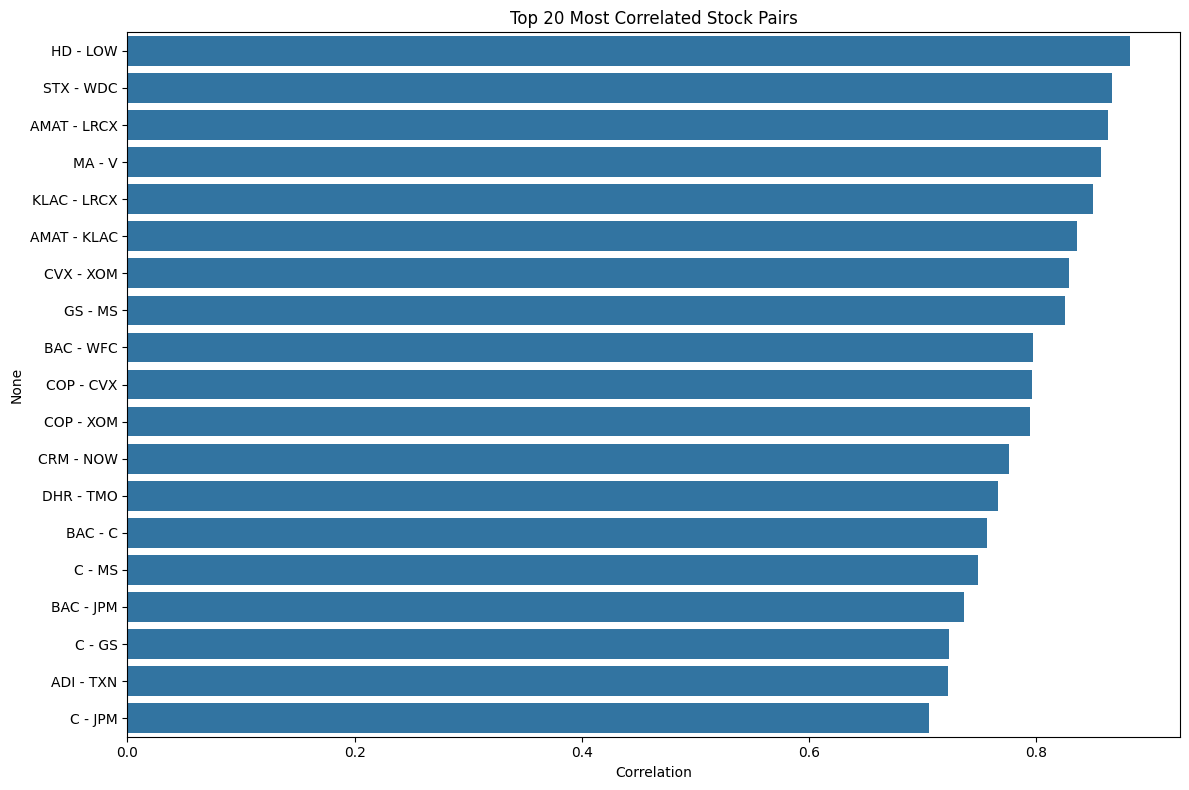

In [75]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_stock_pairs,
    x="Correlation",
    y=top_stock_pairs["Stock_1"]
      + " - "
      + top_stock_pairs["Stock_2"]
)

plt.title(
    "Top 20 Most Correlated Stock Pairs"
)

plt.tight_layout()
plt.show()

In [76]:
sector_info = {}

for ticker in stock_columns:

    try:

        sector_info[ticker] = (
            yf.Ticker(ticker)
            .info
            .get("sector")
        )

        time.sleep(0.5)

    except Exception:

        sector_info[ticker] = "Unknown"

In [77]:
top_stock_pairs["Sector_1"] = (
    top_stock_pairs["Stock_1"]
    .map(sector_info)
)


top_stock_pairs["Sector_2"] = (
    top_stock_pairs["Stock_2"]
    .map(sector_info)
)

top_stock_pairs.head()

,Stock_1,Stock_2,Correlation,Company_1,Company_2,Sector_1,Sector_2
3585,HD,LOW,0.882509,"The Home Depot, Inc.","Lowe's Companies, Inc.",Consumer Cyclical,Consumer Cyclical
7249,STX,WDC,0.867159,Seagate Technology Holdings plc,Western Digital Corporation,Technology,Technology
424,AMAT,LRCX,0.862974,"Applied Materials, Inc.",Lam Research Corporation,Technology,Technology
5015,MA,V,0.857096,Mastercard Incorporated,Visa Inc.,Financial Services,Financial Services
4330,KLAC,LRCX,0.850372,KLA Corporation,Lam Research Corporation,Technology,Technology


# 17. ETF Correlation Matrix

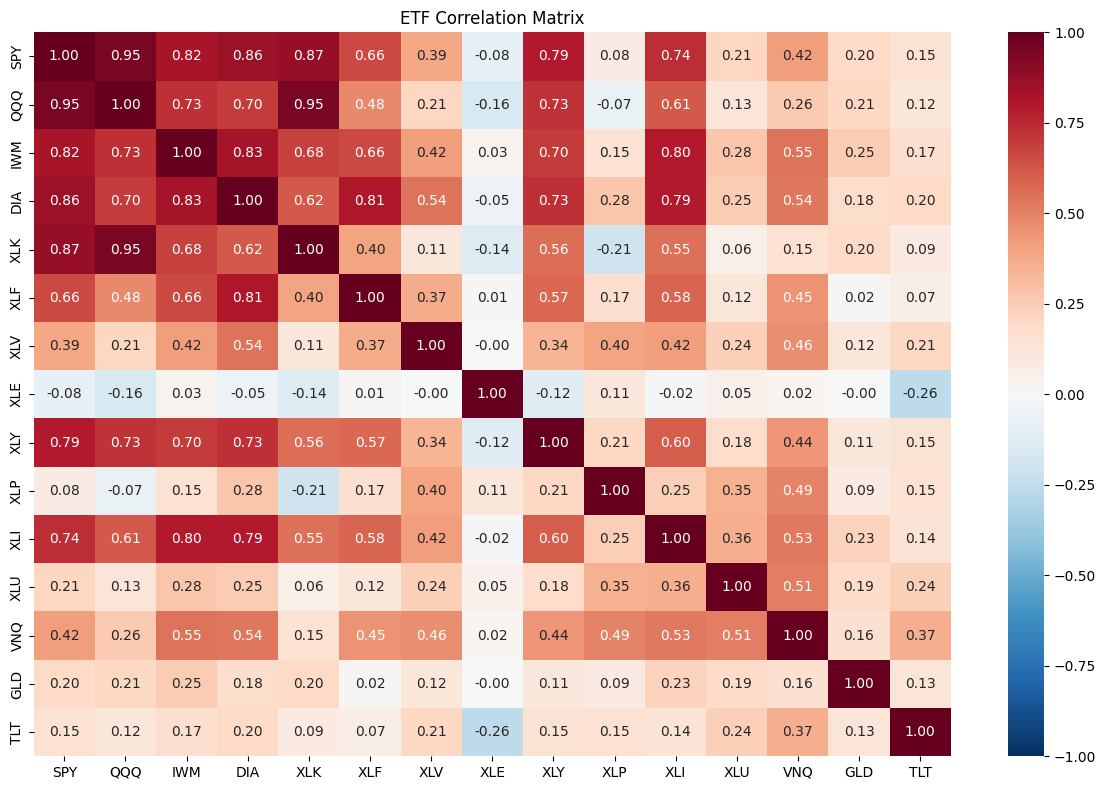

In [78]:
etf_corr = recent_etf_returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    etf_corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f"
)
plt.title("ETF Correlation Matrix")

plt.tight_layout()
plt.show()

## 18. Top Correlated ETF Pairs

In [79]:
upper_etf = etf_corr.where(
    np.triu(
        np.ones(etf_corr.shape),
        k=1
    ).astype(bool)
)

top_etf_pairs = (
    upper_etf
    .stack()
    .reset_index()
)

top_etf_pairs.columns = [
    "ETF_1",
    "ETF_2",
    "Correlation"
]

top_etf_pairs = (
    top_etf_pairs
    .sort_values(
        "Correlation",
        ascending=False
    )
    .head(15)
)

top_etf_pairs

,ETF_1,ETF_2,Correlation
1,SPY,QQQ,0.947339
19,QQQ,XLK,0.945834
4,SPY,XLK,0.873599
3,SPY,DIA,0.855689
33,IWM,DIA,0.830175
2,SPY,IWM,0.824939
50,DIA,XLF,0.812350
40,IWM,XLI,0.796736
8,SPY,XLY,0.791944
55,DIA,XLI,0.789715


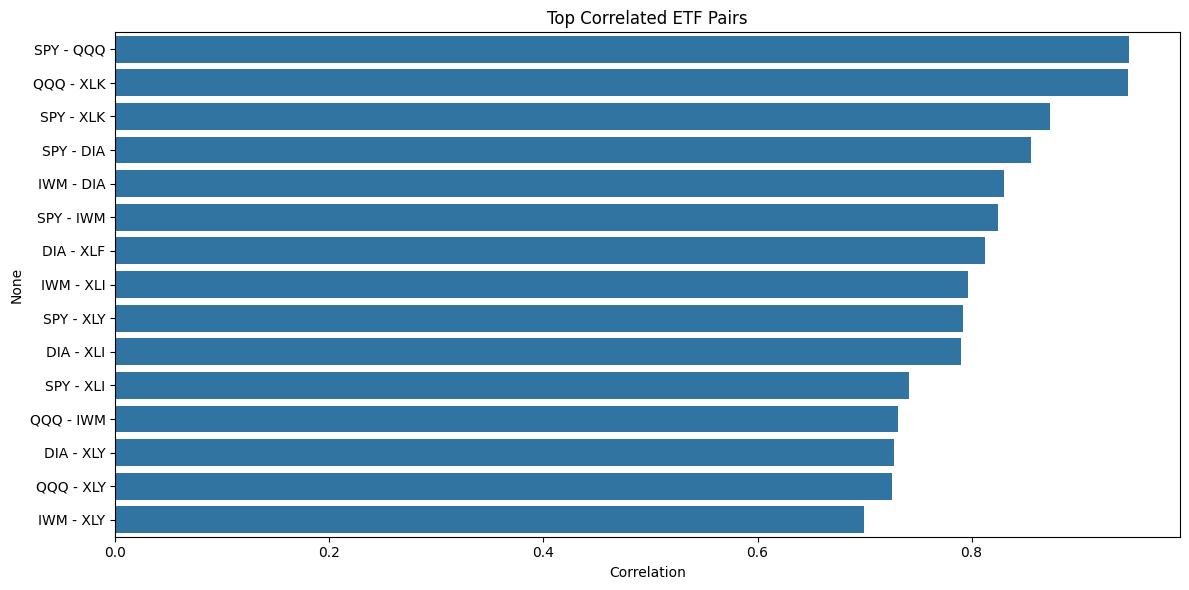

In [80]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_etf_pairs,
    x="Correlation",
    y=(
        top_etf_pairs["ETF_1"]
        + " - "
        + top_etf_pairs["ETF_2"]
    )
)

plt.title(
    "Top Correlated ETF Pairs"
)

plt.tight_layout()
plt.show()

## 19. Stocks vs. ETFs Comparison

To assess whether ETFs offer more stable relationships than individual stocks, the two groups are compared across correlation behaviour, correlation stability, and volatility.

### 19.1 Distribution of Pairwise Correlations

In [81]:
# Convert correlation matrix to pairwise format and remove same-company pairs before calculating
# average stock correlation and correlation distribution.

all_stock_pairs = (upper_stock.stack().reset_index())
all_stock_pairs.columns = [ "Stock_1","Stock_2","Correlation"]
all_stock_pairs = remove_same_company_pairs(all_stock_pairs, "Stock_1","Stock_2")

stock_corr_values = all_stock_pairs["Correlation"]
etf_corr_values = upper_etf.stack()

print("Average Stock Correlation:")
print(round(stock_corr_values.mean(), 3))

print()

print("Average ETF Correlation:")
print(round(etf_corr_values.mean(), 3))

print()

print("Stock Correlation Std:")
print(round(stock_corr_values.std(), 3))

print()

print("ETF Correlation Std:")
print(round(etf_corr_values.std(), 3))

Average Stock Correlation:
0.111

Average ETF Correlation:
0.327

Stock Correlation Std:
0.17

ETF Correlation Std:
0.287


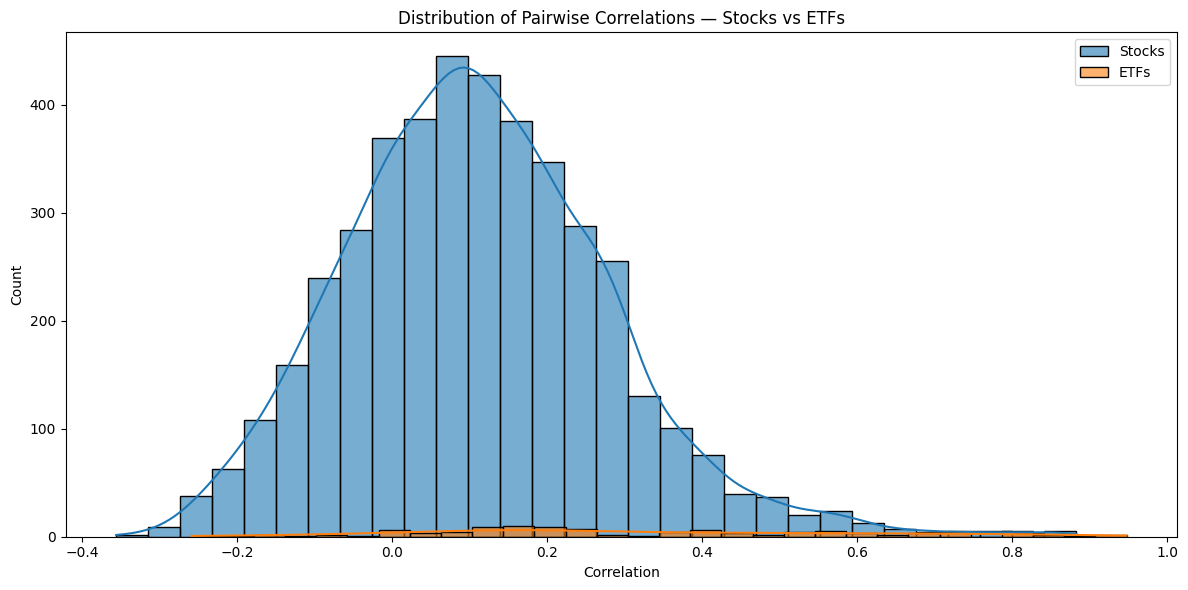

In [82]:
plt.figure(figsize=(12,6))

sns.histplot(
    stock_corr_values,
    bins=30,
    kde=True,
    label="Stocks",
    alpha=0.6
)

sns.histplot(
    etf_corr_values,
    bins=30,
    kde=True,
    label="ETFs",
    alpha=0.6
)

plt.legend()

plt.title(
    "Distribution of Pairwise Correlations — Stocks vs ETFs"
)

plt.xlabel("Correlation")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

### 19.2 Volatility Comparison

In [83]:
stock_volatility = (recent_stock_returns.std()* np.sqrt(252))

etf_volatility = (recent_etf_returns.std()* np.sqrt(252))

comparison = pd.DataFrame({
    "Stocks": [stock_volatility.mean()],
    "ETFs": [etf_volatility.mean()]
})

comparison

,Stocks,ETFs
0,0.318951,0.159869


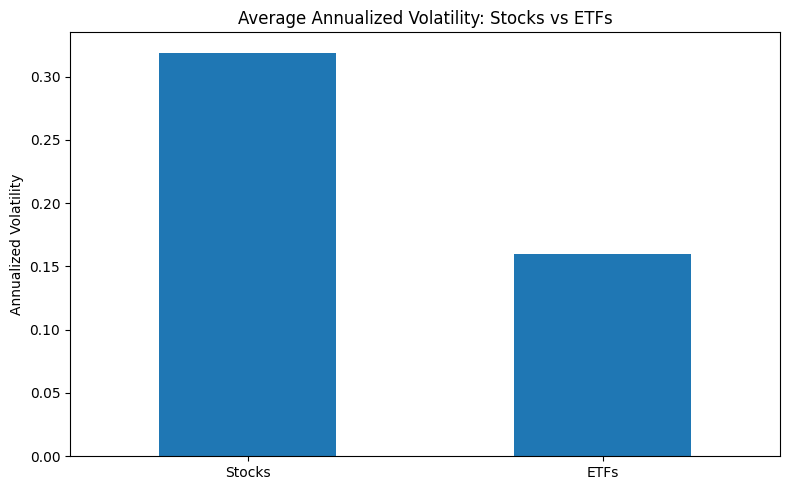

In [84]:
comparison.T.plot(
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.ylabel(
    "Annualized Volatility"
)

plt.title(
    "Average Annualized Volatility: Stocks vs ETFs"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

**Key Finding:**

- ETFs exhibit higher average pairwise correlations than individual stocks, which is expected given that ETFs track diversified baskets of securities.
- The standard deviation of ETF pairwise correlations is lower than for stocks, indicating more consistent relationships across ETF pairs.
- Stocks exhibit higher average annualized volatility than ETFs, reflecting the diversification benefit of ETFs — firm-specific risk is largely diversified away within an ETF basket.
- Because ETF relationships are driven primarily by broad market and sector factors rather than idiosyncratic events, they may be more persistent over time — a useful property when identifying pairs for further analysis.

## 20. Year-wise Correlation Analysis

Long-term average correlations may obscure important changes in relationships that occur across different market regimes. Analysing correlations year by year reveals how relationships evolve over time.

A static correlation estimated over the full sample is an average across all regimes — periods of risk-on, risk-off, sector rotations, and macro shocks. Year-wise analysis makes these structural changes visible.

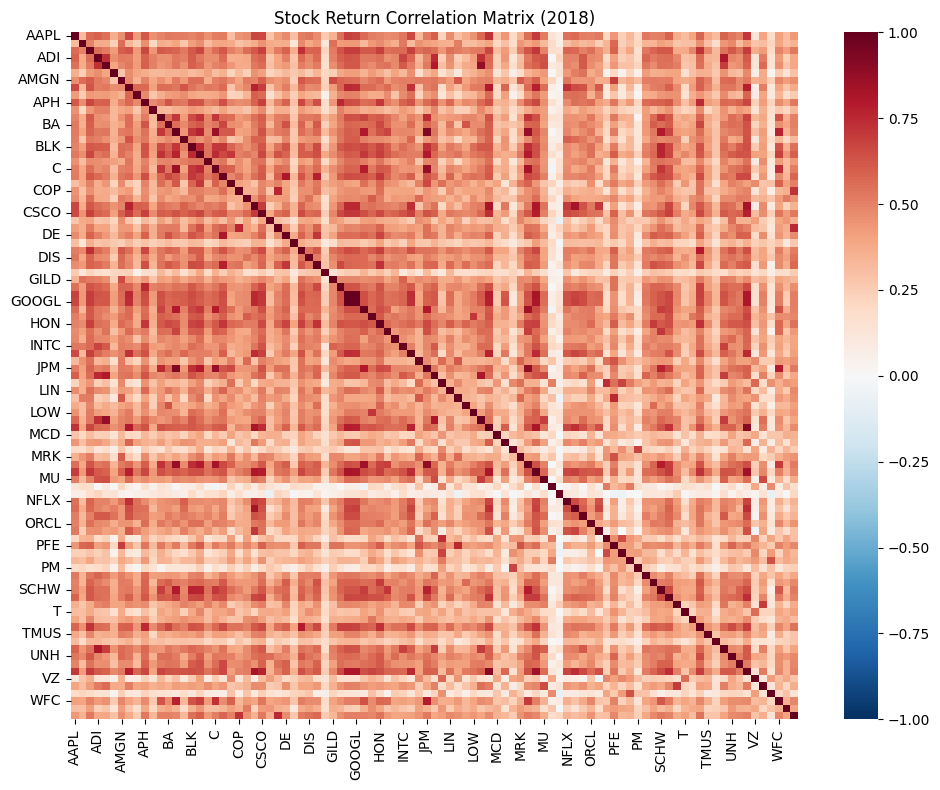



Top 5 Correlated Pairs — 2018
     Stock_1 Stock_2  Correlation                    Company_1  \
1254     BAC     JPM     0.932454  Bank of America Corporation   
5015      MA       V     0.914003      Mastercard Incorporated   
4243     JPM      MS     0.883711         JPMorgan Chase & Co.   
424     AMAT    LRCX     0.881776      Applied Materials, Inc.   
1267     BAC      MS     0.873104  Bank of America Corporation   

                     Company_2  
1254      JPMorgan Chase & Co.  
5015                 Visa Inc.  
4243            Morgan Stanley  
424   Lam Research Corporation  
1267            Morgan Stanley  


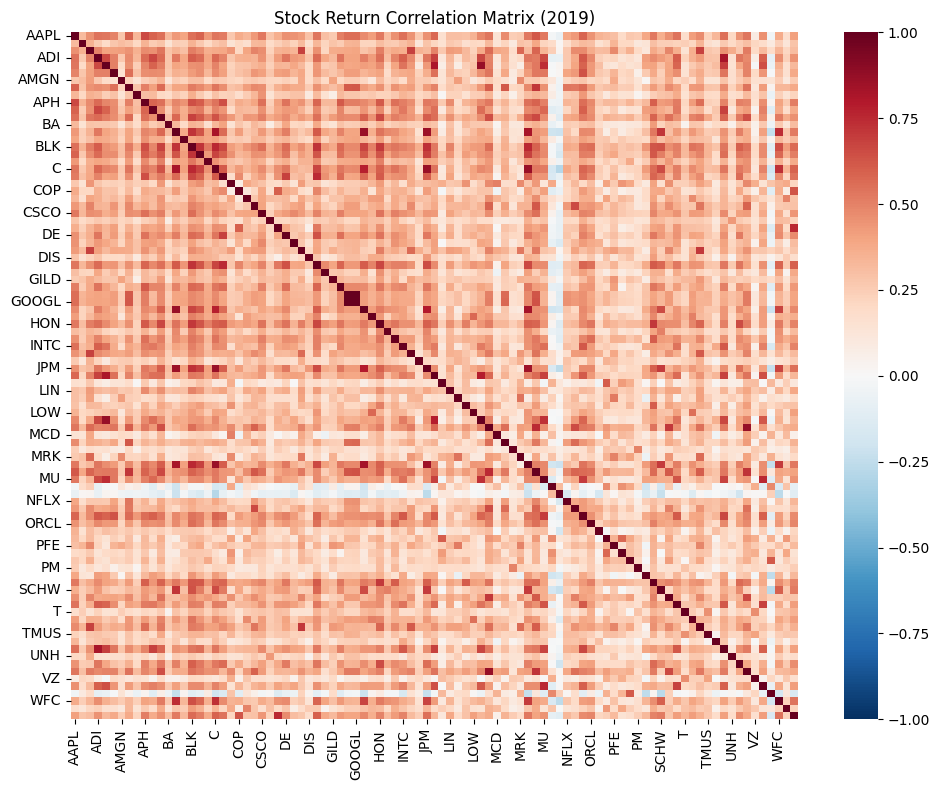



Top 5 Correlated Pairs — 2019
     Stock_1 Stock_2  Correlation                    Company_1  \
424     AMAT    LRCX     0.874613      Applied Materials, Inc.   
5015      MA       V     0.867474      Mastercard Incorporated   
1719       C     JPM     0.866011               Citigroup Inc.   
1246     BAC      GS     0.860420  Bank of America Corporation   
1732       C      MS     0.859549               Citigroup Inc.   

                          Company_2  
424        Lam Research Corporation  
5015                      Visa Inc.  
1719           JPMorgan Chase & Co.  
1246  The Goldman Sachs Group, Inc.  
1732                 Morgan Stanley  


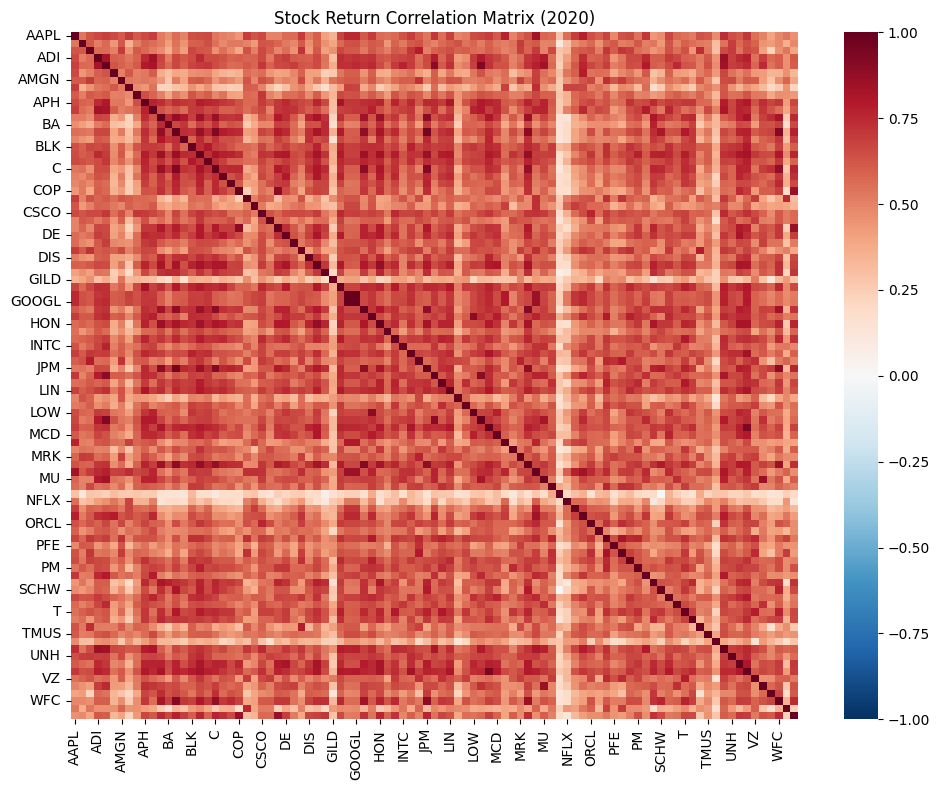



Top 5 Correlated Pairs — 2020
     Stock_1 Stock_2  Correlation                      Company_1  \
1254     BAC     JPM     0.953740    Bank of America Corporation   
5015      MA       V     0.942210        Mastercard Incorporated   
424     AMAT    LRCX     0.927714        Applied Materials, Inc.   
1227     BAC       C     0.926720    Bank of America Corporation   
3499      GS      MS     0.917180  The Goldman Sachs Group, Inc.   

                     Company_2  
1254      JPMorgan Chase & Co.  
5015                 Visa Inc.  
424   Lam Research Corporation  
1227            Citigroup Inc.  
3499            Morgan Stanley  


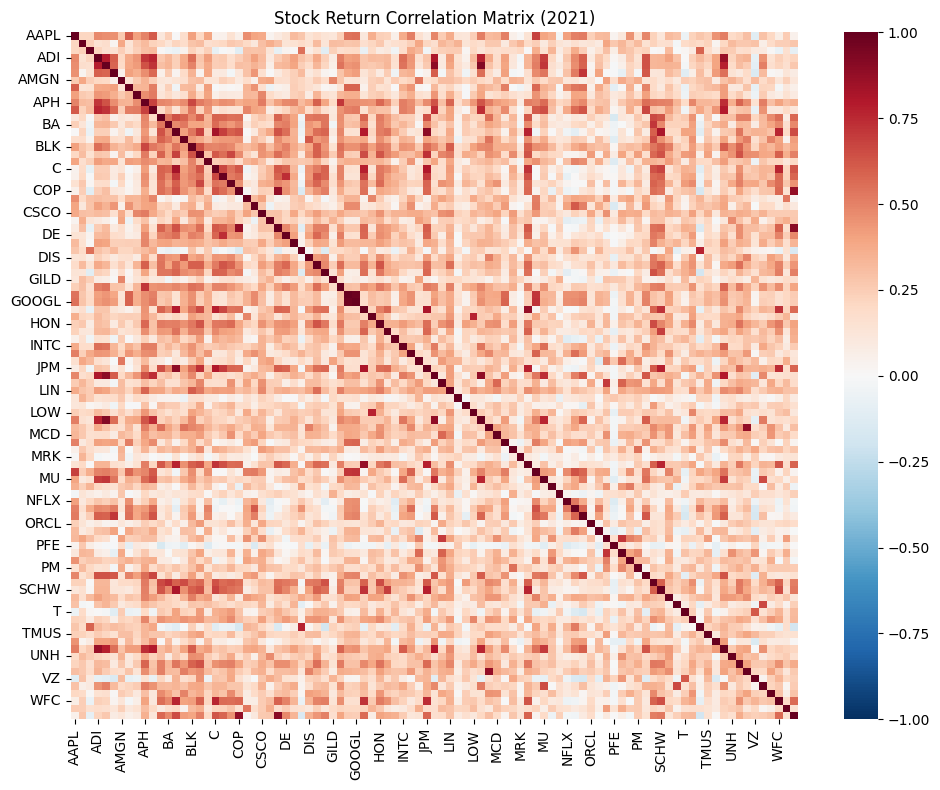



Top 5 Correlated Pairs — 2021
     Stock_1 Stock_2  Correlation                    Company_1  \
424     AMAT    LRCX     0.918455      Applied Materials, Inc.   
2510     CVX     XOM     0.904808          Chevron Corporation   
1254     BAC     JPM     0.895762  Bank of America Corporation   
418     AMAT    KLAC     0.894590      Applied Materials, Inc.   
4330    KLAC    LRCX     0.886740              KLA Corporation   

                     Company_2  
424   Lam Research Corporation  
2510   Exxon Mobil Corporation  
1254      JPMorgan Chase & Co.  
418            KLA Corporation  
4330  Lam Research Corporation  


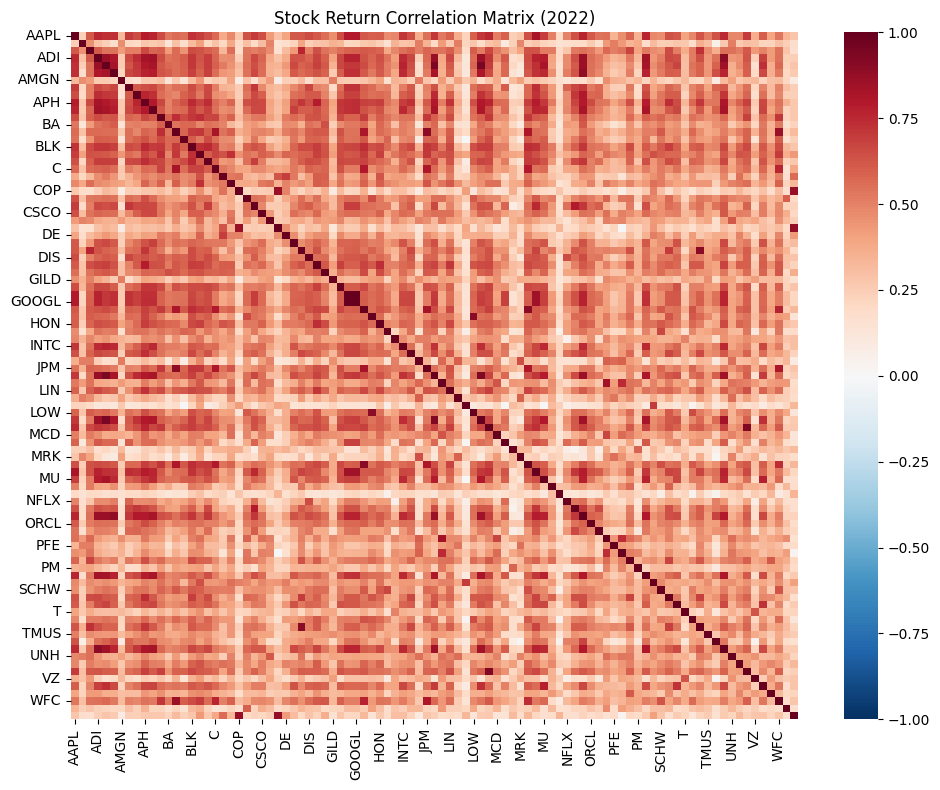



Top 5 Correlated Pairs — 2022
     Stock_1 Stock_2  Correlation                      Company_1  \
424     AMAT    LRCX     0.945555        Applied Materials, Inc.   
418     AMAT    KLAC     0.937541        Applied Materials, Inc.   
4330    KLAC    LRCX     0.934810                KLA Corporation   
5015      MA       V     0.925411        Mastercard Incorporated   
3499      GS      MS     0.900271  The Goldman Sachs Group, Inc.   

                     Company_2  
424   Lam Research Corporation  
418            KLA Corporation  
4330  Lam Research Corporation  
5015                 Visa Inc.  
3499            Morgan Stanley  


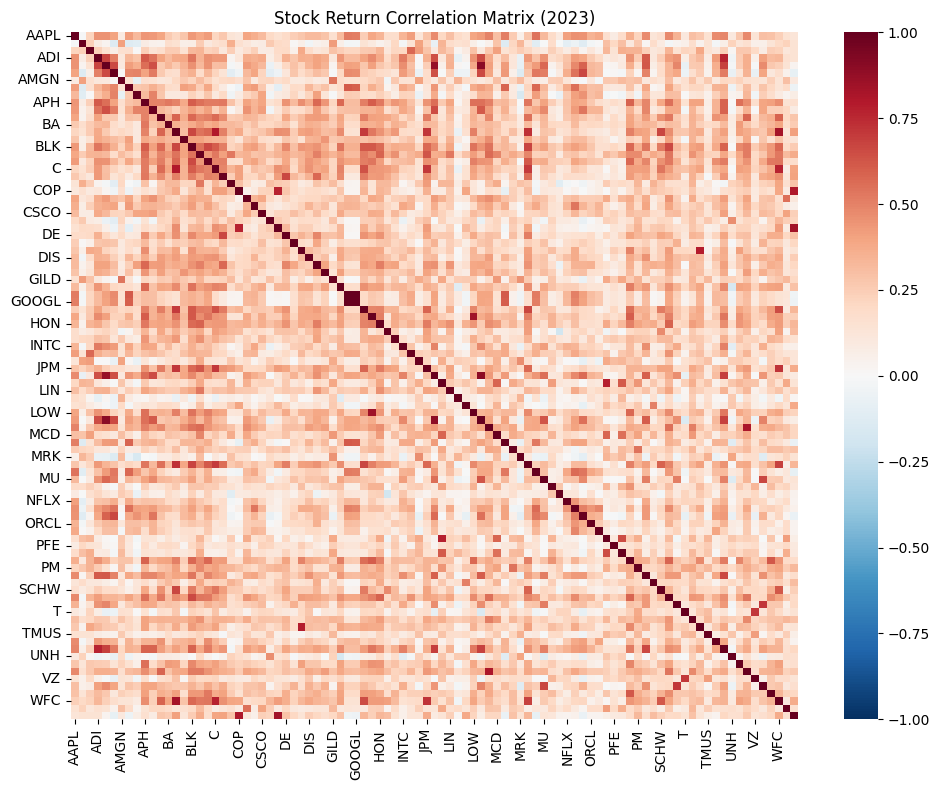



Top 5 Correlated Pairs — 2023
     Stock_1 Stock_2  Correlation                Company_1  \
424     AMAT    LRCX     0.904734  Applied Materials, Inc.   
4330    KLAC    LRCX     0.893602          KLA Corporation   
418     AMAT    KLAC     0.874433  Applied Materials, Inc.   
3585      HD     LOW     0.850853     The Home Depot, Inc.   
2510     CVX     XOM     0.840412      Chevron Corporation   

                     Company_2  
424   Lam Research Corporation  
4330  Lam Research Corporation  
418            KLA Corporation  
3585    Lowe's Companies, Inc.  
2510   Exxon Mobil Corporation  


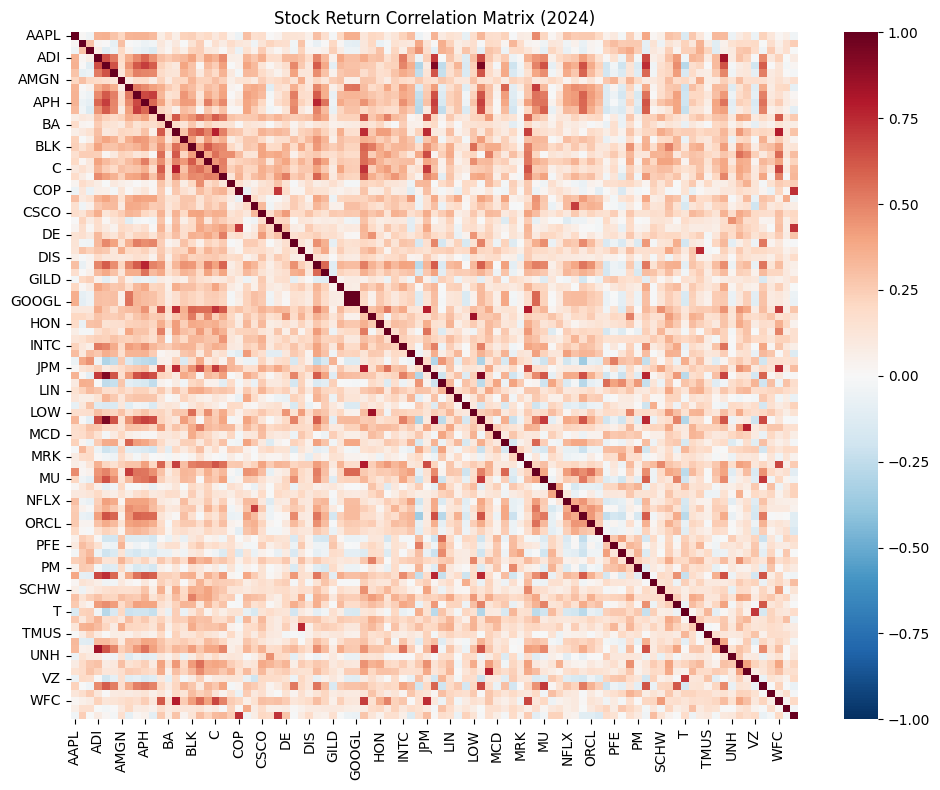



Top 5 Correlated Pairs — 2024
     Stock_1 Stock_2  Correlation                Company_1  \
424     AMAT    LRCX     0.937842  Applied Materials, Inc.   
418     AMAT    KLAC     0.926916  Applied Materials, Inc.   
4330    KLAC    LRCX     0.917107          KLA Corporation   
3585      HD     LOW     0.848490     The Home Depot, Inc.   
362      ADI     TXN     0.840643     Analog Devices, Inc.   

                           Company_2  
424         Lam Research Corporation  
418                  KLA Corporation  
4330        Lam Research Corporation  
3585          Lowe's Companies, Inc.  
362   Texas Instruments Incorporated  


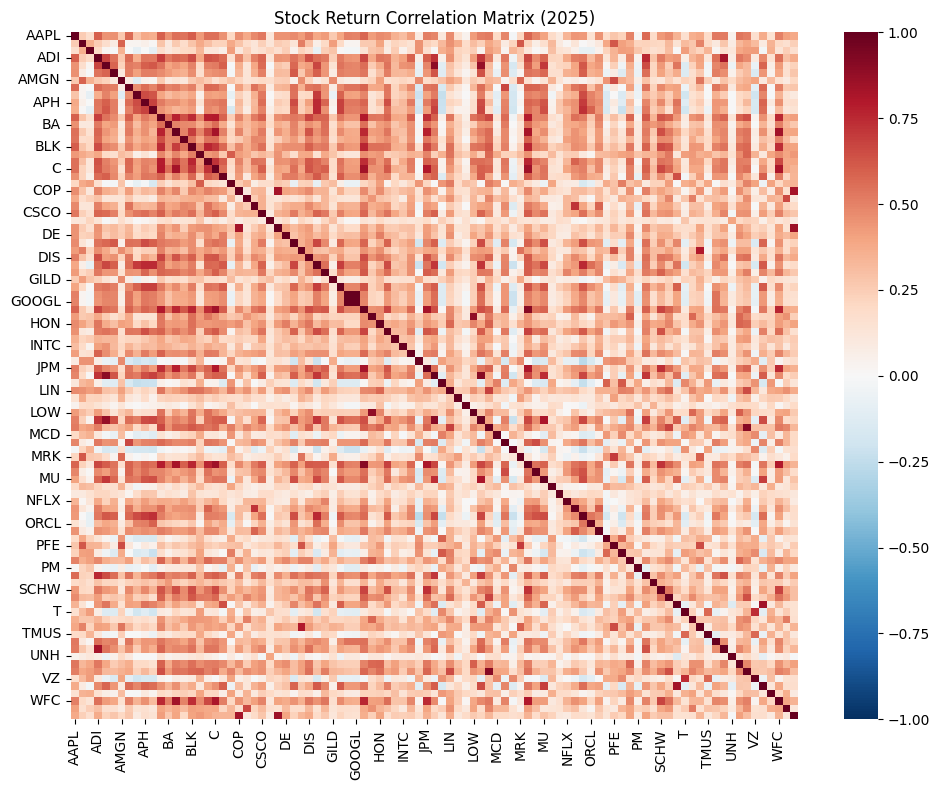



Top 5 Correlated Pairs — 2025
     Stock_1 Stock_2  Correlation                      Company_1  \
3499      GS      MS     0.913762  The Goldman Sachs Group, Inc.   
4330    KLAC    LRCX     0.912693                KLA Corporation   
5015      MA       V     0.912208        Mastercard Incorporated   
418     AMAT    KLAC     0.893117        Applied Materials, Inc.   
3585      HD     LOW     0.886905           The Home Depot, Inc.   

                     Company_2  
3499            Morgan Stanley  
4330  Lam Research Corporation  
5015                 Visa Inc.  
418            KLA Corporation  
3585    Lowe's Companies, Inc.  


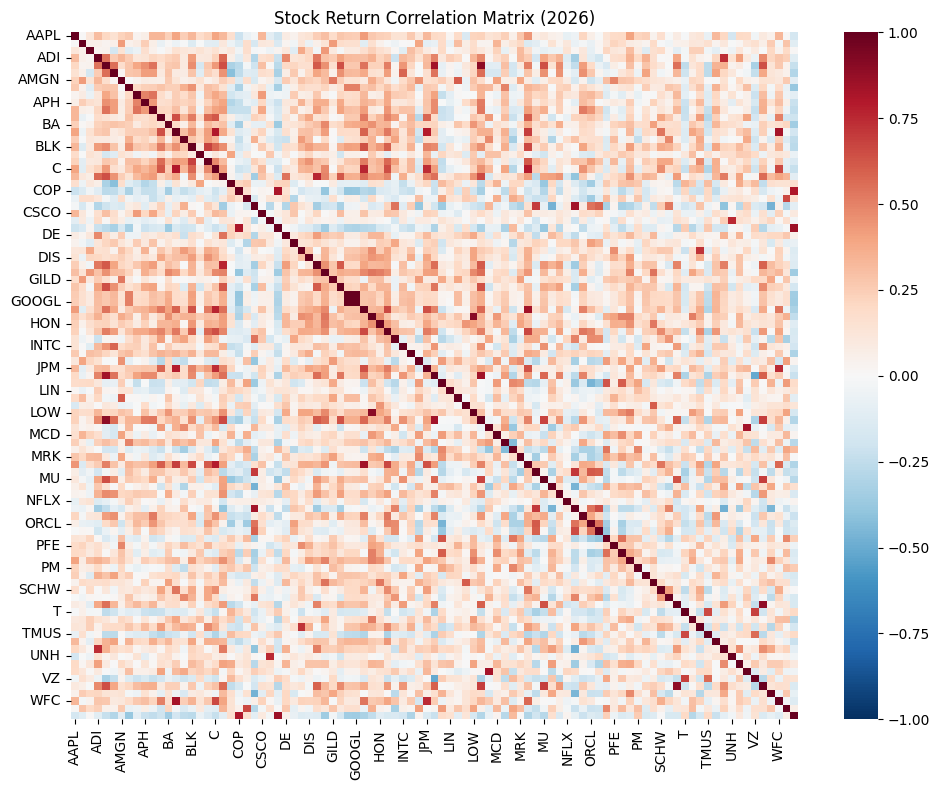



Top 5 Correlated Pairs — 2026
     Stock_1 Stock_2  Correlation                        Company_1  \
3585      HD     LOW     0.904864             The Home Depot, Inc.   
424     AMAT    LRCX     0.891163          Applied Materials, Inc.   
7249     STX     WDC     0.884725  Seagate Technology Holdings plc   
2510     CVX     XOM     0.852928              Chevron Corporation   
2203     CRM     NOW     0.841859                 Salesforce, Inc.   

                        Company_2  
3585       Lowe's Companies, Inc.  
424      Lam Research Corporation  
7249  Western Digital Corporation  
2510      Exxon Mobil Corporation  
2203             ServiceNow, Inc.  


In [85]:
years = sorted(returns.index.year.unique())

yearly_top_pairs = {}

for year in years:

    yearly_data = stock_returns[
        stock_returns.index.year == year
    ]

    if len(yearly_data) < 60:
        print(f"Skipping {year}")
        continue

    yearly_corr = yearly_data.corr()

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        yearly_corr,
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1
    )

    plt.title(
        f"Stock Return Correlation Matrix ({year})"
    )

    plt.tight_layout()
    plt.show()

    upper_yr = yearly_corr.where(
        np.triu(np.ones(yearly_corr.shape),k=1).astype(bool)
    )

    pairs = upper_yr.stack().reset_index()

    pairs.columns = [
        "Stock_1",
        "Stock_2",
        "Correlation"
    ]

    pairs = remove_same_company_pairs(
        pairs,
        "Stock_1",
        "Stock_2"
    )

    pairs = ( pairs.sort_values("Correlation",ascending=False).head(5))

    yearly_top_pairs[year] = pairs

    print("\n")
    print("=" * 50)
    print(f"Top 5 Correlated Pairs — {year}")
    print("=" * 50)
    print(pairs)

- Same-company pairs (e.g. GOOG–GOOGL) are excluded from year-wise results 
  by the same-company filter applied in each loop iteration.
- Year-wise analysis covers stock pairs only; ETF relationships are 
  examined separately in Section 21.2.
- Semiconductor pairs (AMAT–LRCX, AMAT–KLAC) and financial pairs 
  (BAC–JPM, MA–V) are among the most consistently recurring relationships.

In [86]:
from collections import Counter

pair_counter = Counter()

for year, pairs in yearly_top_pairs.items():

    for _, row in pairs.iterrows():

        pair_name = (
            row["Stock_1"]
            + " - "
            + row["Stock_2"]
        )

        pair_counter[pair_name] += 1

pair_frequency = (
    pd.DataFrame(
        pair_counter.items(),
        columns=[
            "Pair",
            "Years Appeared in Top 5"
        ]
    )
    .sort_values(
        "Years Appeared in Top 5",
        ascending=False
    )
)

print(
    "Pairs appearing most frequently in the yearly top-5:"
)

pair_frequency

Pairs appearing most frequently in the yearly top-5:


,Pair,Years Appeared in Top 5
3,AMAT - LRCX,8
12,KLAC - LRCX,5
11,AMAT - KLAC,5
1,MA - V,5
13,HD - LOW,4
0,BAC - JPM,3
10,CVX - XOM,3
9,GS - MS,3
15,STX - WDC,1
14,ADI - TXN,1


### Sector Relationship Analysis

Most highly correlated stock pairs belong to the same industry or sector.

This suggests that common business drivers and industry-specific factors play a major role in determining return correlations.

## 21. Rolling Correlation Analysis

Static correlation provides a single relationship estimate over the entire sample period. However, relationships between assets can change through time.

To evaluate relationship stability, a 252-day rolling correlation window is used.

Why 252?

- Approximately 252 trading days occur in one year.
- The window captures long-term relationship dynamics.
- Rolling correlation helps identify periods where relationships strengthen or weaken.

In [87]:
# Helper function to compute rolling correlation
def compute_rolling_corr(data, asset1, asset2, window=252):
    return data[asset1].rolling(window).corr(data[asset2])

In [88]:
full_stock_corr = stock_returns.corr()

full_etf_corr = etf_returns.corr()

In [89]:
# Top 5 stock pairs for rolling correlation

top_stock_pairs_5 = top_stock_pairs.head(5)

stock_pairs_to_plot = list(
    zip(
        top_stock_pairs_5["Stock_1"],
        top_stock_pairs_5["Stock_2"]
    )
)

# Top 5 ETF pairs for rolling correlation

top_etf_pairs_5 = top_etf_pairs.head(5)

etf_pairs_to_plot = list(
    zip(
        top_etf_pairs_5["ETF_1"],
        top_etf_pairs_5["ETF_2"]
    )
)

print("Stock Pairs:")
print(stock_pairs_to_plot)

print()

print("ETF Pairs:")
print(etf_pairs_to_plot)

Stock Pairs:
[('HD', 'LOW'), ('STX', 'WDC'), ('AMAT', 'LRCX'), ('MA', 'V'), ('KLAC', 'LRCX')]

ETF Pairs:
[('SPY', 'QQQ'), ('QQQ', 'XLK'), ('SPY', 'XLK'), ('SPY', 'DIA'), ('IWM', 'DIA')]


## 21.1 Rolling Correlation — Stocks

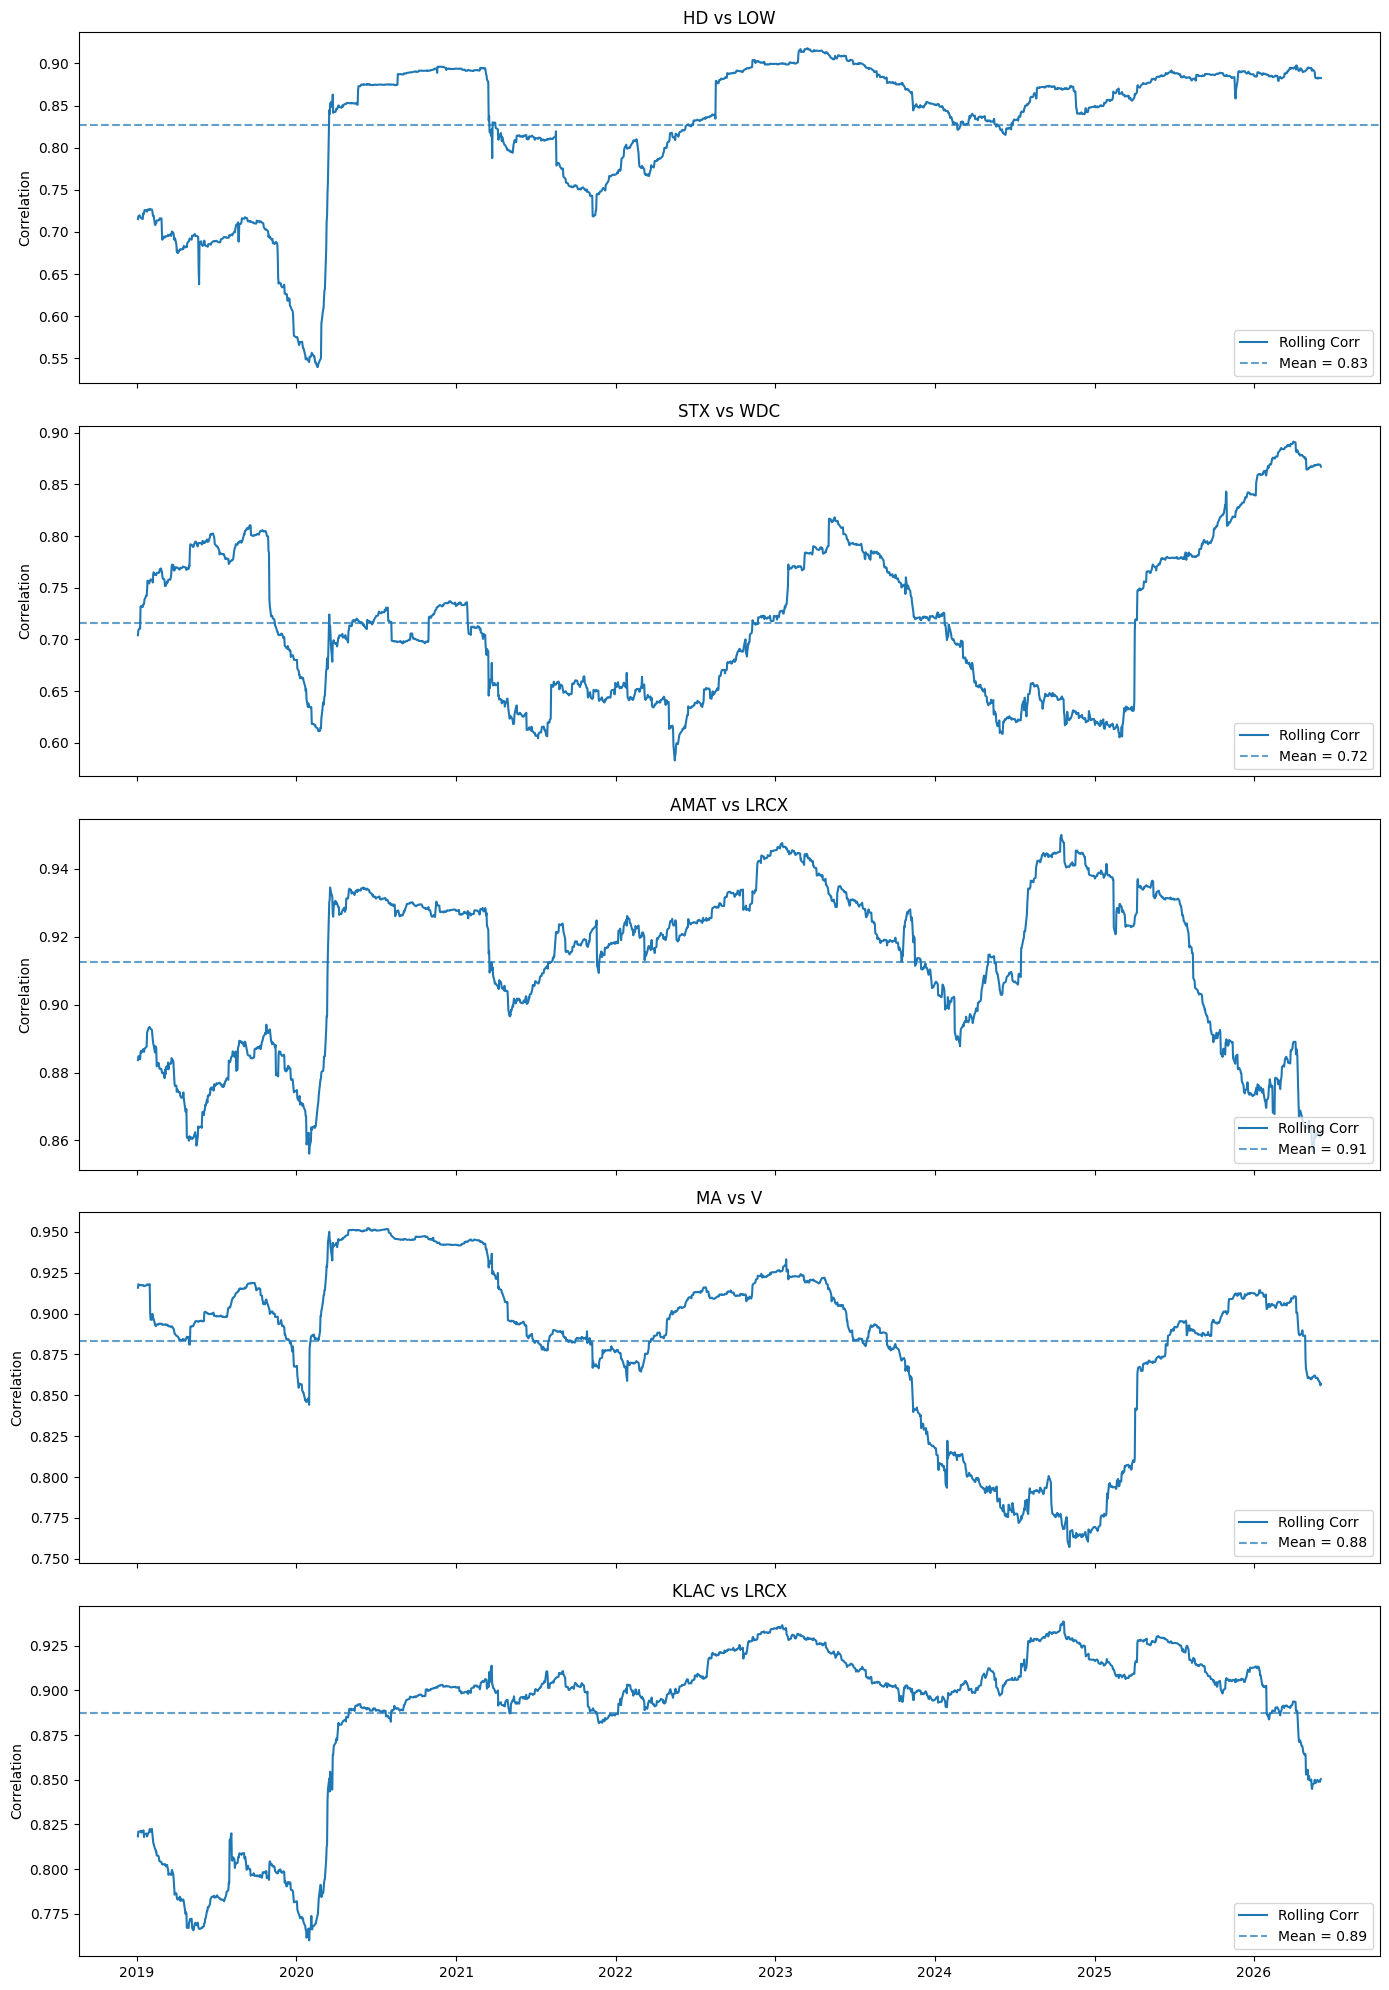

In [90]:
fig, axes = plt.subplots(
    len(stock_pairs_to_plot),
    1,
    figsize=(14, 4 * len(stock_pairs_to_plot)),
    sharex=True
)

if len(stock_pairs_to_plot) == 1:
    axes = [axes]

for ax, (s1, s2) in zip(axes, stock_pairs_to_plot):

    rcorr = compute_rolling_corr(stock_returns, s1, s2, 252).dropna()

    ax.plot(rcorr.index, rcorr, label="Rolling Corr")

    ax.axhline(        
    rcorr.mean(),        
    linestyle="--",
    alpha=0.7,
    label=f"Mean = {rcorr.mean():.2f}"
)                       
    ax.legend(loc="lower right")
    ax.set_title(f"{s1} vs {s2}")
    ax.set_ylabel("Correlation")

plt.tight_layout()
plt.show()

In [91]:
rolling_summary = []
# Summary cell
for s1, s2 in stock_pairs_to_plot:
    rcorr = compute_rolling_corr(stock_returns, s1, s2).dropna()
    rolling_summary.append({
        "Pair":              f"{s1}-{s2}",
        "Static Corr":       round(full_stock_corr.loc[s1, s2], 3),
        "Mean Rolling Corr": round(rcorr.mean(), 3),
        "Min Rolling Corr":  round(rcorr.min(), 3),
        "Max Rolling Corr":  round(rcorr.max(), 3),
        "Std Rolling Corr":  round(rcorr.std(), 3),
    })


rolling_summary = pd.DataFrame(
    rolling_summary
)

rolling_summary

,Pair,Static Corr,Mean Rolling Corr,Min Rolling Corr,Max Rolling Corr,Std Rolling Corr
0,HD-LOW,0.837,0.827,0.540,0.918,0.081
1,STX-WDC,0.739,0.716,0.583,0.891,0.074
2,AMAT-LRCX,0.911,0.913,0.856,0.950,0.023
3,MA-V,0.903,0.883,0.757,0.952,0.050
4,KLAC-LRCX,0.887,0.887,0.760,0.939,0.045


**Observations (Stocks):** Several stock pairs maintained consistently high rolling correlations across the sample period. Some relationships weakened during periods of market stress, while semiconductor and financial-sector pairs displayed particularly stable relationships.



## 21.2 Rolling Correlation — ETF

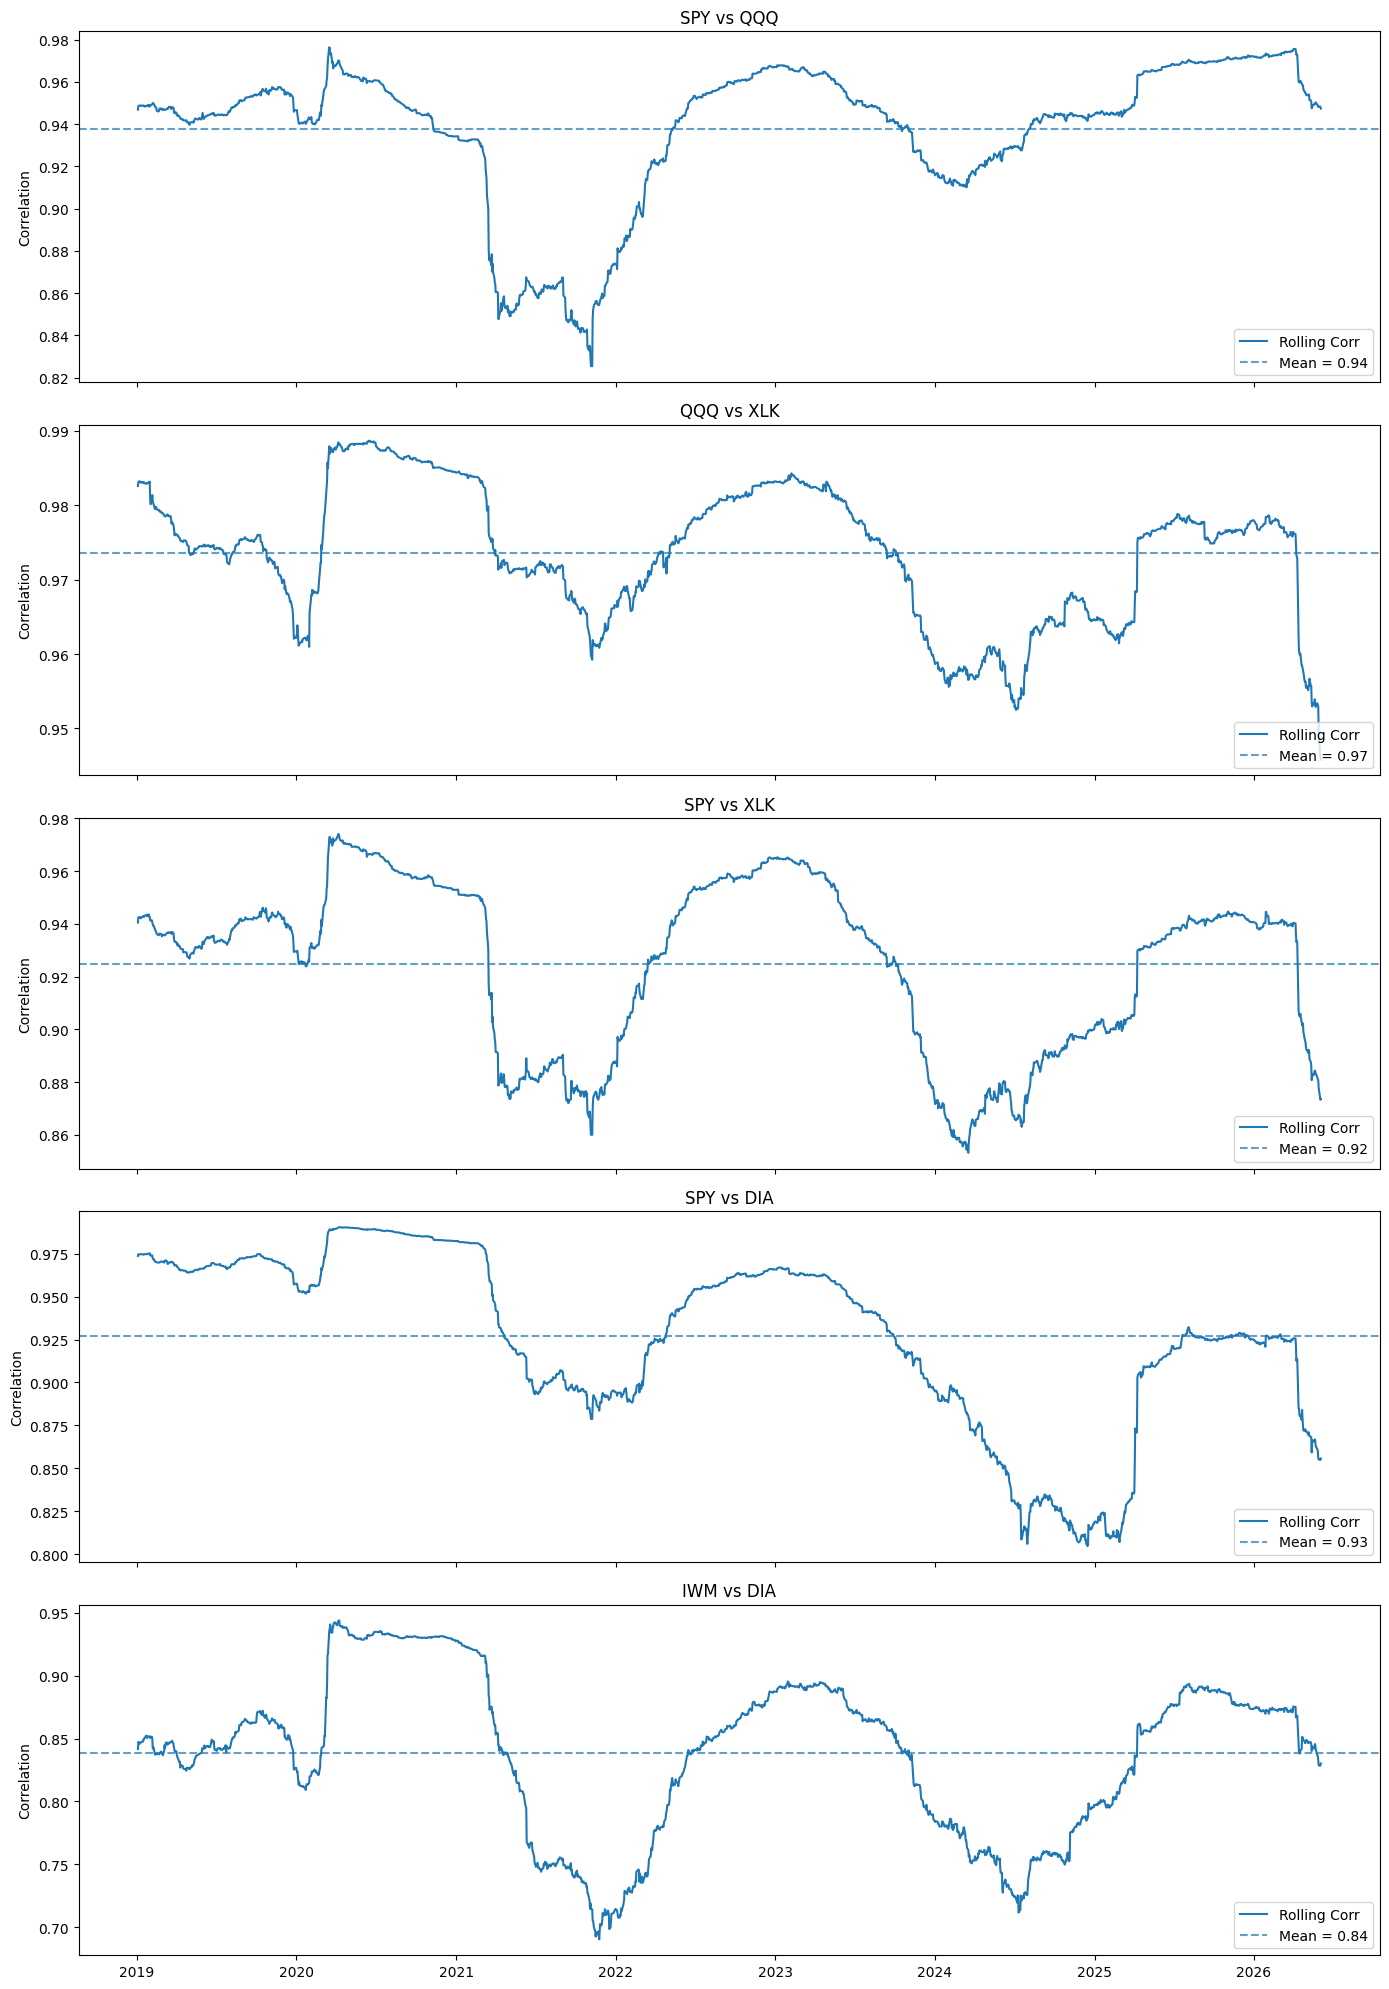

In [92]:
fig, axes = plt.subplots(
    len(etf_pairs_to_plot),
    1,
    figsize=(14, 4 * len(etf_pairs_to_plot)),
    sharex=True
)
if len(etf_pairs_to_plot) == 1:
    axes = [axes]

for ax, (e1, e2) in zip(axes, etf_pairs_to_plot):

    rcorr = compute_rolling_corr(etf_returns, e1, e2, 252).dropna()
    ax.plot(rcorr.index, rcorr, label="Rolling Corr")
    ax.axhline( rcorr.mean(), linestyle="--", alpha=0.7, label=f"Mean = {rcorr.mean():.2f}")
    ax.set_title(f"{e1} vs {e2}")
    ax.set_ylabel("Correlation")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [93]:
# Rolling correlation summary table for ETF pairs
etf_summary = []
for e1, e2 in etf_pairs_to_plot:
    rcorr = compute_rolling_corr(etf_returns, e1, e2).dropna()
    etf_summary.append({
        "Pair": f"{e1} – {e2}",
        "Static Corr":       round(full_etf_corr.loc[e1, e2], 3),
        "Mean Rolling Corr": round(rcorr.mean(), 3),
        "Min Rolling Corr":  round(rcorr.min(), 3),
        "Max Rolling Corr":  round(rcorr.max(), 3),
        "Std Rolling Corr":  round(rcorr.std(), 3)
    })

etf_rolling_summary = pd.DataFrame(etf_summary)
etf_rolling_summary

,Pair,Static Corr,Mean Rolling Corr,Min Rolling Corr,Max Rolling Corr,Std Rolling Corr
0,SPY – QQQ,0.938,0.938,0.825,0.976,0.033
1,QQQ – XLK,0.974,0.974,0.946,0.989,0.009
2,SPY – XLK,0.930,0.925,0.853,0.974,0.032
3,SPY – DIA,0.945,0.927,0.805,0.991,0.050
4,IWM – DIA,0.853,0.839,0.690,0.944,0.062


**Observations (ETFs):** ETF relationships were generally more stable than stock relationships. QQQ–XLK exhibited persistently strong correlation due to overlapping technology holdings. Broad-market ETFs maintained strong relationships throughout the full sample period. The lower standard deviation of rolling correlations for ETF pairs (compared to stock pairs) provides quantitative support for their greater relationship stability.

## 22. Final Summary

In [94]:
print("=" * 70)
print("FINAL EDA SUMMARY")
print("=" * 70)

print("\nDataset Overview")
print("-" * 30)
print(f"Total Assets: {returns.shape[1]}")
print(f"Observation Period: {returns.index.min().date()} to {returns.index.max().date()}")

print("\nPerformance Analysis")
print("-" * 30)
print("Top Performing Assets:")
print(performance.head(5))

print("\nVolatility Analysis")
print("-" * 30)
print("Most Volatile Assets:")
print(top_volatility.head(5))

print("\nLeast Volatile Assets:")
print(low_volatility.head(5))

print("\nCorrelation Analysis (Recent 1-Year Period)")
print("-" * 30)
print("Top Stock Pairs:")
print(top_stock_pairs[["Stock_1", "Stock_2", "Correlation"]].head(5))

print("\nTop ETF Pairs:")
print(top_etf_pairs[["ETF_1", "ETF_2", "Correlation"]].head(5))

print("\nStocks vs ETFs")
print("-" * 30)
print(f"Average Stock Correlation: {stock_corr_values.mean():.3f}")

print(f"Average ETF Correlation: {etf_corr_values.mean():.3f}")

print(f"Average Stock Volatility: {stock_volatility.mean():.3f}")

print(f"Average ETF Volatility: {etf_volatility.mean():.3f}")

print("\nYearly Correlation Stability")
print("-" * 30)

print( pair_frequency.head(10))

print("\nRolling Correlation Summary")
print("-" * 30)

print(
    rolling_summary[
        [
            "Pair",
            "Mean Rolling Corr",
            "Min Rolling Corr",
            "Max Rolling Corr"
        ]
    ]
)
print("\nETF Rolling Correlation Summary")
print("-" * 30)

print(
    etf_rolling_summary[
        [
            "Pair",
            "Mean Rolling Corr",
            "Min Rolling Corr",
            "Max Rolling Corr"
        ]
    ]
)
print("\nKey Findings")
print("-" * 30)

print("• Correlations vary across time and are not constant.")

print("• ETFs generally exhibit stronger and more stable correlations than individual stocks.")

print("• Highly correlated pairs are often concentrated within similar sectors.")

print("• Rolling correlations reveal periods of strengthening and weakening relationships.")

print("• Several stock pairs consistently appear among the most correlated across multiple years.")

print("• Recent one-year analysis provides a more current view of market relationships.")

print("\nEDA Completed Successfully.")

FINAL EDA SUMMARY

Dataset Overview
------------------------------
Total Assets: 108
Observation Period: 2018-01-03 to 2026-06-03

Performance Analysis
------------------------------
Top Performing Assets:
AMD     49.409840
NVDA    43.575172
STX     30.155163
MU      25.347498
AVGO    22.726695
Name: 2026-06-03 00:00:00, dtype: float64

Volatility Analysis
------------------------------
Most Volatile Assets:
TSLA    0.626684
AMD     0.561009
MU      0.513484
NVDA    0.506896
WDC     0.503856
dtype: float64

Least Volatile Assets:
TLT    0.155008
XLP    0.155676
GLD    0.166154
XLV    0.174181
DIA    0.187848
dtype: float64

Correlation Analysis (Recent 1-Year Period)
------------------------------
Top Stock Pairs:
     Stock_1 Stock_2  Correlation
3585      HD     LOW     0.882509
7249     STX     WDC     0.867159
424     AMAT    LRCX     0.862974
5015      MA       V     0.857096
4330    KLAC    LRCX     0.850372

Top ETF Pairs:
   ETF_1 ETF_2  Correlation
1    SPY   QQQ     0.947339
